# Análisis Exploratorio de Datos (EDA)
Este EDA tiene como propósito comprender la estructura, calidad y características del conjunto de datos para sustentar tres objetivos investigativos:

1. **Objetivo 1:** Analizar la relación entre la marca/modelo del vehículo y la gravedad del accidente para identificar patrones de riesgo.
2. **Objetivo 2:** Evaluar los factores asociados a la edad del vehículo y su relación con la gravedad del accidente.
3. **Objetivo 3:** Identificar la concentración espacial y los patrones temporales (semanal, mensual y anual) de los siniestros en Colombia.

El análisis sigue la siguiente estructura:
1. Carga y exploración inicial
2. Calidad de datos (nulos, tipos, duplicados)
3. Tratamiento de datos (imputación, outliers, filtros)
4. Ingeniería de variables derivadas
5. Distribuciones univariadas
6. Análisis bivariado (variable a variable con la gravedad)
7. Análisis temporal
8. Análisis geográfico
9. Análisis inferencial (pruebas estadísticas formales)
10. Conclusiones, limitaciones y preparación para modelado

---
## 1. Carga y exploración inicial

### 1.1 Librerías

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

plt.style.use('ggplot')
%matplotlib inline
sns.set_palette("Blues")
import warnings
warnings.filterwarnings("ignore")

### 1.2 Carga del dataset

In [81]:
df = pd.read_csv(
    'VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv',
    encoding='latin-1'
)
print(f"Dimensiones del dataset: {df.shape[0]:,} registros × {df.shape[1]} variables")
df["ID_REGISTRO"] = range(1, len(df) + 1)

Dimensiones del dataset: 406,540 registros × 9 variables


In [82]:
df.head()

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO,ID_REGISTRO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,1
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,3
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,4
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,5


In [83]:
df.tail()

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO,ID_REGISTRO
406535,BAJAJ,2015,MOTOCICLETA,11.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA,406536
406536,YAMAHA,2005,MOTOCICLETA,21.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA,406537
406537,AKT,2022,MOTOCICLETA,4.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA,406538
406538,SIGMA,2008,MOTOCICLETA,18.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA,406539
406539,SIGMA,2020,MOTOCICLETA,4.0,01/2022,CON HERIDOS,ATLANTICO,BARRANQUILLA,STRIA DTAL TTO BARRANQUILLA,406540


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   MARCA_VEHICULO          406496 non-null  object
 1   MODELO_VEHICULO         406540 non-null  int64 
 2   TIPO_VEHICULO           406540 non-null  object
 3   EDAD_VEHICULO           406520 non-null  object
 4   FECHA_ACCIDENTE         406540 non-null  object
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object
 9   ID_REGISTRO             406540 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 31.0+ MB


El dataset cuenta con **406,540 registros** y **9 variables**. Cada registro representa un vehículo involucrado en un accidente, no un accidente como evento único.

La mayoría de las variables son categóricas, pero para las variables `EDAD_VEHICULO` y `MODELO_VEHICULO` están cargadas como `object` pero deberían ser numéricas.

La variable `FECHA_ACCIDENTE` está en formato texto y debe convertirse a `datetime`.

Y se detectan valores faltantes en `MARCA_VEHICULO` y `EDAD_VEHICULO` que se analizarán en detalle.

**Nota:** El hecho de que la unidad de análisis sea el *vehículo* y no el *accidente* implica que un choque entre tres vehículos genera tres registros independientes. Esto es una limitación estructural del dataset que debe tenerse en cuenta al interpretar los conteos.

In [85]:
# Corrección de tipos de datos
df['EDAD_VEHICULO']   = pd.to_numeric(df['EDAD_VEHICULO'],   errors='coerce')
df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')
df['FECHA_ACCIDENTE'] = pd.to_datetime('01/' + df['FECHA_ACCIDENTE'], format='%d/%m/%Y')
df["ID_REGISTRO"] = df["ID_REGISTRO"].astype("category")

print("Tipos de datos corregidos:")
print(df[['EDAD_VEHICULO','MODELO_VEHICULO','FECHA_ACCIDENTE']].dtypes)

Tipos de datos corregidos:
EDAD_VEHICULO             float64
MODELO_VEHICULO             int64
FECHA_ACCIDENTE    datetime64[ns]
dtype: object


Pasar EDAD_VEHICULO a numérico se vio que de object pasó a float64, no int64, puede ser que hayan presencia de valores nulos.

In [86]:
df.drop(columns=["FECHA_ACCIDENTE"]).describe()

,MODELO_VEHICULO,EDAD_VEHICULO
count,406540.000000,406519.000000
mean,2015.587573,10.465449
std,7.817606,7.461105
min,1937.000000,0.000000
25%,2012.000000,5.000000
50%,2017.000000,9.000000
75%,2021.000000,14.000000
max,2027.000000,126.000000


En `MODELO_VEHICULO` vemos que va de **1937 a 2027** — hay años futuros e históricos extremos que son errores de registro. 
En `EDAD_VEHICULO` alcanza **126 años**, físicamente imposible en el contexto vial colombiano.

La **media de edad** es ≈10.5 años y la mediana es 9 años, indicando que la mitad de los vehículos accidentados tienen menos de 9 años.

---
## 2. Calidad de datos

### 2.1 Valores nulos

In [87]:
# Resumen de nulos
def resumen_nulos(df):
    total = df.isnull().sum()
    pct   = (total / len(df)) * 100
    return pd.DataFrame({'Nulos': total, 'Porcentaje (%)': pct.round(4)}).query('Nulos > 0')

resumen_nulos(df)

,Nulos,Porcentaje (%)
MARCA_VEHICULO,44,0.0108
EDAD_VEHICULO,21,0.0052


In [88]:
# Patrón de nulos por tipo de vehículo
nulos_por_tipo = df.isnull().groupby(df['TIPO_VEHICULO']).sum()
print("Nulos en MARCA_VEHICULO y EDAD_VEHICULO por tipo de vehículo:")
print(nulos_por_tipo[['MARCA_VEHICULO', 'EDAD_VEHICULO']].query('MARCA_VEHICULO > 0 or EDAD_VEHICULO > 0'))

Nulos en MARCA_VEHICULO y EDAD_VEHICULO por tipo de vehículo:
                 MARCA_VEHICULO  EDAD_VEHICULO
TIPO_VEHICULO                                 
AUTOMOVIL                     0              5
CAMIONETA                     0              3
CARGADOR                      3              0
COMPACTADOR                   1              0
EXCAVADORA                    2              0
FRESADORA                     2              0
MINICARGADOR                  3              0
MONTACARGAS                   8              0
MOTOCICLETA                   0             13
MOTONIVELADORA                1              0
PAVIMENTADORA                 1              0
REMOLQUE                      1              0
RETROEXCAVADORA               5              0
SEMIREMOLQUE                  1              0
TRACTOR                      16              0


Los nulos en `MARCA_VEHICULO` (0.01%) se concentran exclusivamente en tipos como TRACTOR, MONTACARGAS y RETROEXCAVADORA. Estos vehículos de maquinaria industrial no tienen una "marca comercial" estándar en el registro de tránsito, por lo que el valor faltante es **estructural, no un error de captura**. La estrategia es rellenar con `"Sin información"`.

Los nulos en `EDAD_VEHICULO` (0.005%) aparecen en MOTOCICLETA, AUTOMÓVIL y CAMIONETA, lo que sugiere omisión en la digitación o ausencia del campo `MODELO_VEHICULO` que sirve para calcularla. La estrategia es **imputar con la mediana por tipo de vehículo**.

### 2.2 Duplicados

In [89]:
df_sin_id = df.drop(columns=["ID_REGISTRO"])
df_sin_id.duplicated().sum()

147575

In [90]:
df_sin_id = df.drop(columns=["ID_REGISTRO"])

df_duplicados = df[df_sin_id.duplicated(keep=False)]
df_duplicados.head(20)

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO,ID_REGISTRO
4,HONDA,2026,MOTOCICLETA,1.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,5
5,BERA,2025,MOTOCICLETA,0.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,6
10,CHEVROLET,2016,AUTOMOVIL,11.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,11
11,HONDA,2026,MOTOCICLETA,1.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,12
19,BERA,2025,MOTOCICLETA,0.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,20
20,CHEVROLET,2018,AUTOMOVIL,9.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,21
24,CHEVROLET,2009,AUTOMOVIL,17.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,25
25,HONDA,2016,MOTOCICLETA,10.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,26
26,CHEVROLET,2007,AUTOMOVIL,19.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,27
28,BERA,2025,MOTOCICLETA,0.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,29


### 2.3 Distribución de la variable objetivo

In [91]:
print("Distribución de GRAVEDAD_ACCIDENTE:")
g = df['GRAVEDAD_ACCIDENTE'].value_counts()
for cat, cnt in g.items():
    print(f"  {cat:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")

Distribución de GRAVEDAD_ACCIDENTE:
  CON HERIDOS             385,881  (94.92%)
  CON MUERTOS              20,659  (5.08%)


**La variable objetivo presenta desbalanceo de clases:** CON HERIDOS representa ~95% y CON MUERTOS ~5%. 

---
## 3. Tratamiento de datos

### 3.1 Imputación de valores nulos

In [92]:
# MARCA_VEHICULO: nulos estructurales → "Sin información"
df['MARCA_VEHICULO'] = df['MARCA_VEHICULO'].fillna("Sin información")

# EDAD_VEHICULO: imputar con mediana por TIPO_VEHICULO
# Justificación: diferentes tipos de vehículo tienen distribuciones de edad muy distintas.
# Una mediana global introduciría sesgo (ej. la edad típica de una moto ≠ la de un camión).
df['EDAD_VEHICULO'] = df.groupby('TIPO_VEHICULO')['EDAD_VEHICULO'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback global para tipos con todos los valores nulos
df['EDAD_VEHICULO'] = df['EDAD_VEHICULO'].fillna(df['EDAD_VEHICULO'].median())

print("Nulos después de imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos después de imputación:
Series([], dtype: int64)


### 3.2 Detección y tratamiento de outliers

**EDAD_VEHICULO**

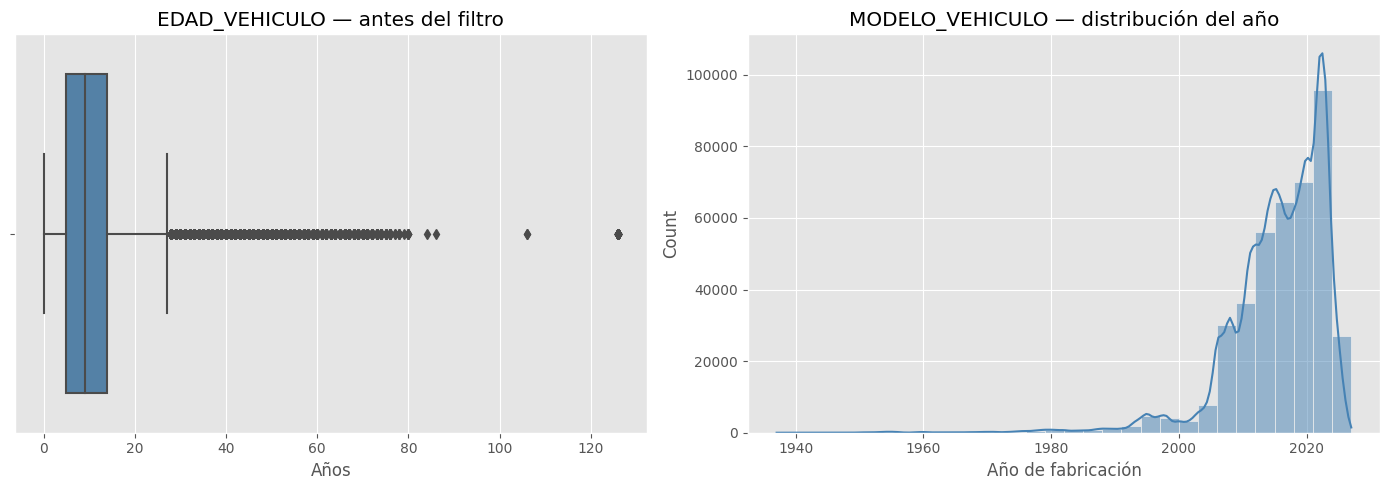

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['EDAD_VEHICULO'], ax=axes[0], color='steelblue')
axes[0].set_title('EDAD_VEHICULO — antes del filtro')
axes[0].set_xlabel('Años')

sns.histplot(df['MODELO_VEHICULO'], bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('MODELO_VEHICULO — distribución del año')
axes[1].set_xlabel('Año de fabricación')

plt.tight_layout()
plt.show()

En la variable `EDAD_VEHICULO` muestra valores de hasta 126 años — físicamente imposibles.
En `MODELO_VEHICULO` presenta años anteriores a 1940 (errores de digitación) y años de 2026-2027 (la fecha más reciente del dataset es diciembre de 2025, por lo que esos modelos son inválidos).

Es posible que existan vehículos clásicos de colección en circulación, pero los registros de las décadas de 1930-1940 son sospechosos de error de captura. Se establece **1950 como límite inferior** para `MODELO_VEHICULO`.

Para `EDAD_VEHICULO` se aplica un **cap de 60 años**, umbral que cubre incluso los vehículos de colección más longevos que razonablemente circulan.

In [94]:
antes = len(df)

# Filtros de MODELO_VEHICULO
df = df[(df['MODELO_VEHICULO'] >= 1950) & (df['MODELO_VEHICULO'] <= 2025)]
print(f"Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: {antes - len(df):,}")

# Cap de EDAD_VEHICULO
antes2 = len(df)
df = df[df['EDAD_VEHICULO'] <= 60]
print(f"Eliminados por EDAD_VEHICULO > 60 años: {antes2 - len(df):,}")
print(f"Registros restantes: {len(df):,}")

Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: 2,964
Eliminados por EDAD_VEHICULO > 60 años: 449
Registros restantes: 403,127


### 3.3 Filtros de calidad temporal

Se identificaron dos problemas de calidad en la dimensión temporal que requieren tratamiento antes del análisis:

In [95]:
# Extraer componentes temporales
df['AÑO']      = df['FECHA_ACCIDENTE'].dt.year
df['MES']      = df['FECHA_ACCIDENTE'].dt.month
df['MES_NOMBRE'] = df['FECHA_ACCIDENTE'].dt.month_name()
df['SEMESTRE']   = df['FECHA_ACCIDENTE'].apply(lambda x: 1 if x.month <= 6 else 2)
df['DIA_SEMANA'] = df['FECHA_ACCIDENTE'].dt.day_name(locale='es_ES')

print("Componentes temporales extraídos correctamente.")
print(df[['FECHA_ACCIDENTE','AÑO','MES','DIA_SEMANA']].head(3))

Componentes temporales extraídos correctamente.
  FECHA_ACCIDENTE   AÑO  MES DIA_SEMANA
0      2025-12-01  2025   12      Lunes
1      2025-12-01  2025   12      Lunes
2      2025-12-01  2025   12      Lunes


In [96]:
# Excluir 2026 (año incompleto, distorsiona tasas de mortalidad)
df = df[df['AÑO'] <= 2025]
print(f"Registros tras excluir 2026: {len(df):,}")

Registros tras excluir 2026: 401,137


---
## 4. Variables derivadas

Se crean nuevas variables que enriquecen el análisis y son relevantes para los tres objetivos.

In [97]:
# MODELO_ESPECIFICO (marca + año de fabricación)
# La marca sola tiene baja asociación con la gravedad (V de Cramér débil).
# Al combinarla con el año se captura la variación dentro de cada marca.
df['MODELO_ESPECIFICO'] = df['MARCA_VEHICULO'].astype(str) + ' ' + df['MODELO_VEHICULO'].astype(str)

# ANTIGÜEDAD_VEHICULO y su categorización
# ANTIGÜEDAD es el cálculo preciso desde el año del accidente,
# mientras que EDAD_VEHICULO es la variable original.
df['ANTIGÜEDAD_VEHICULO'] = df['FECHA_ACCIDENTE'].dt.year - df['MODELO_VEHICULO']

bins_edad   = [0, 5, 10, 20, float('inf')]
labels_edad = ['0-5 años', '6-10 años', '11-20 años', '>20 años']
df['CAT_EDAD_VEHICULO'] = pd.cut(df['ANTIGÜEDAD_VEHICULO'], bins=bins_edad, labels=labels_edad)

In [98]:
# Variables temporales adicionales ──
meses_vacaciones  = [1, 6, 7, 12]
meses_alto_riesgo = [7, 9, 3, 5]   # Basado en estacionalidad observada
df['ES_VACACIONES']     = df['MES'].isin(meses_vacaciones).astype(int)
df['ES_MES_ALTO_RIESGO'] = df['MES'].isin(meses_alto_riesgo).astype(int)

print("Variables derivadas creadas:")
print(f"  MODELO_ESPECIFICO   → {df['MODELO_ESPECIFICO'].nunique():,} combinaciones únicas")
print(f"  ANTIGÜEDAD_VEHICULO → media = {df['ANTIGÜEDAD_VEHICULO'].mean():.1f} años")
print(f"  CAT_EDAD_VEHICULO   → {df['CAT_EDAD_VEHICULO'].value_counts().to_dict()}")
print(f"  ES_VACACIONES       → {df['ES_VACACIONES'].sum():,} registros en períodos vacacionales")

Variables derivadas creadas:
  MODELO_ESPECIFICO   → 2,977 combinaciones únicas
  ANTIGÜEDAD_VEHICULO → media = 7.7 años
  CAT_EDAD_VEHICULO   → {'0-5 años': 133999, '6-10 años': 103334, '11-20 años': 94079, '>20 años': 19355}
  ES_VACACIONES       → 143,339 registros en períodos vacacionales


---
## 5. Distribuciones univariadas

Análisis de cada variable de forma individual, sin cruzar con la variable objetivo.

### 5.1 Variables categóricas

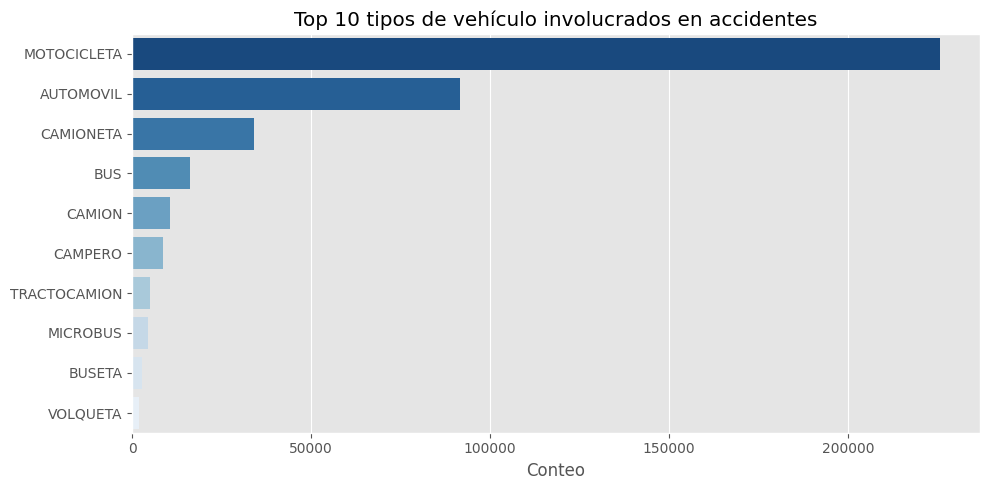

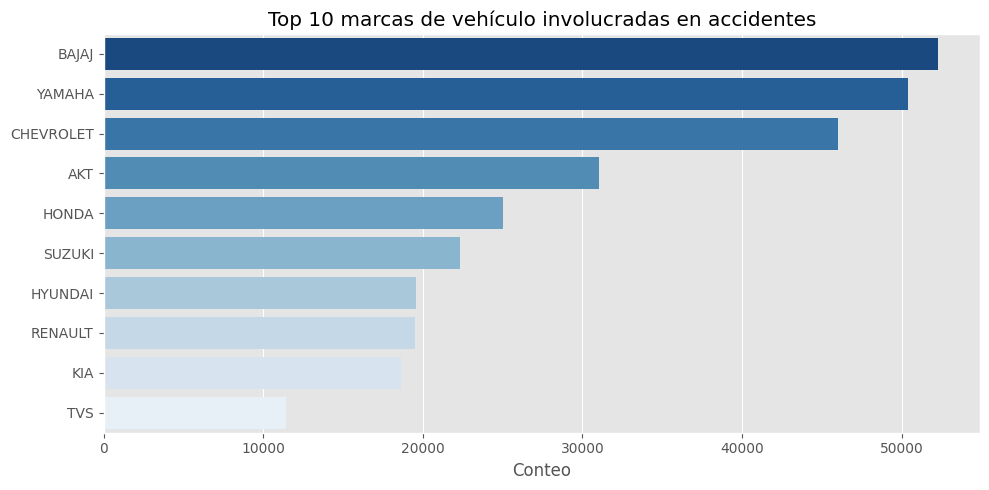

In [99]:
def distribucion_categorica(df, columna, top_n=None, titulo=None):
    if top_n:
        top_cats = df[columna].value_counts().nlargest(top_n).index
        data, order = df[df[columna].isin(top_cats)], top_cats
    else:
        data, order = df, df[columna].value_counts().index
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=data, y=columna, order=order, palette='Blues_r', ax=ax)
    ax.set_title(titulo or f'Distribución de {columna}')
    ax.set_xlabel('Conteo')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

distribucion_categorica(df, 'TIPO_VEHICULO', top_n=10, titulo='Top 10 tipos de vehículo involucrados en accidentes')
distribucion_categorica(df, 'MARCA_VEHICULO', top_n=10, titulo='Top 10 marcas de vehículo involucradas en accidentes')

**Hallazgos univariados — categóricas:**
- **Tipo de vehículo:** Las motocicletas dominan con una cifra que supera la suma de los siguientes nueve tipos combinados. Automóviles y camionetas conforman el segundo y tercer lugar.
- **Marca:** El top 10 está liderado por marcas de motocicletas (BAJAJ, YAMAHA, AKT, HONDA, SUZUKI), seguidas por automóviles (CHEVROLET, RENAULT, HYUNDAI, KIA). Esta distribución refleja el parque automotor colombiano, no un riesgo inherente de la marca.

### 5.2 Variables numéricas

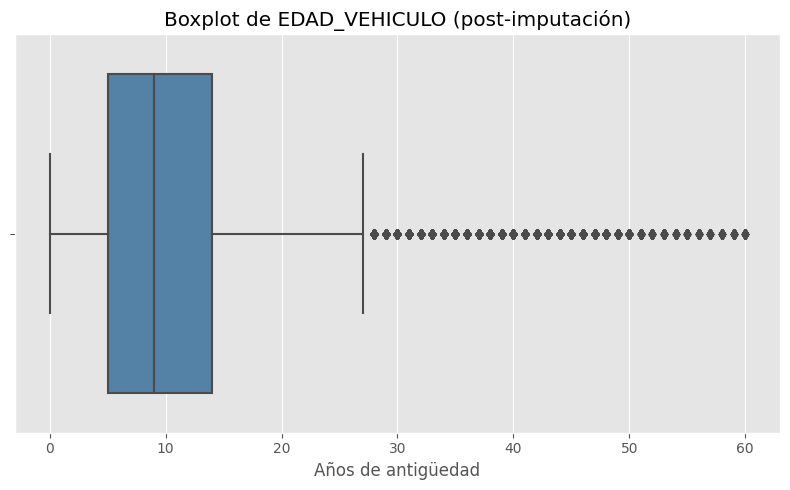

EDAD_VEHICULO → Media: 10.5 años | Mediana: 9.0 años


In [100]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    x=df['EDAD_VEHICULO'],
    color='steelblue',        # color más visible
    linewidth=1.5,       # bordes más definidos
    fliersize=5,         # tamaño de outliers
    ax=ax
)

ax.set_title('Boxplot de EDAD_VEHICULO (post-imputación)')
ax.set_xlabel('Años de antigüedad')

plt.tight_layout()
plt.show()

print(f"EDAD_VEHICULO → Media: {df['EDAD_VEHICULO'].mean():.1f} años | Mediana: {df['EDAD_VEHICULO'].median():.1f} años")

En `EDAD_VEHICULO` muestra una distribución con **sesgo positivo** (cola a la derecha): la mayoría de los vehículos involucrados en accidentes tienen entre 0 y 20 años.

---
## 6. Análisis bivariado

Cruce de cada variable explicativa con `GRAVEDAD_ACCIDENTE`. Esta sección sustenta directamente los tres objetivos.

### 6.1 Tipo de vehículo vs. Gravedad 

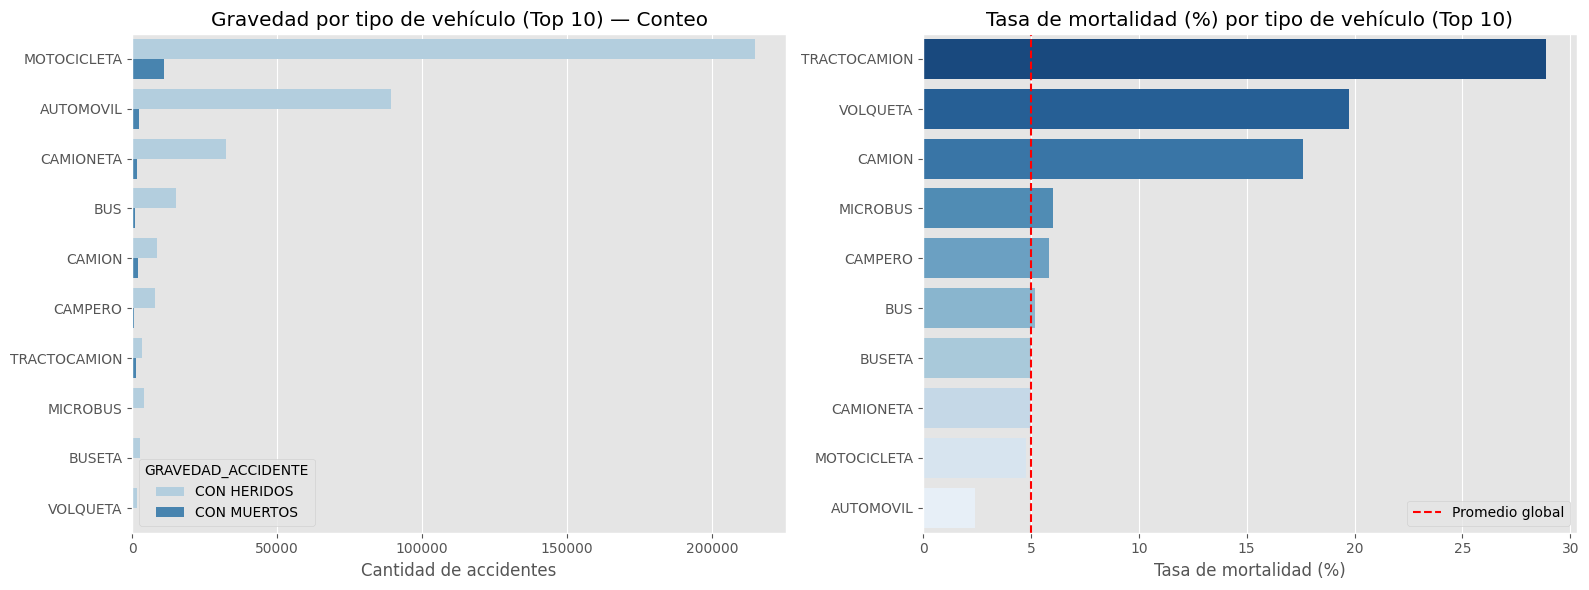

In [101]:
top_tipos = df['TIPO_VEHICULO'].value_counts().nlargest(10).index
df_tipos_top = df[df['TIPO_VEHICULO'].isin(top_tipos)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Conteo absoluto
sns.countplot(data=df_tipos_top, y='TIPO_VEHICULO', hue='GRAVEDAD_ACCIDENTE',
              order=top_tipos, palette='Blues', ax=axes[0])
axes[0].set_title('Gravedad por tipo de vehículo (Top 10) — Conteo')
axes[0].set_xlabel('Cantidad de accidentes')
axes[0].set_ylabel('')

# Tasa de mortalidad
tasa_tipo = df_tipos_top.groupby('TIPO_VEHICULO')['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reindex(top_tipos).sort_values(ascending=False)

sns.barplot(x=tasa_tipo.values, y=tasa_tipo.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Tasa de mortalidad (%) por tipo de vehículo (Top 10)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')
axes[1].axvline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Marca y modelo vs. Gravedad

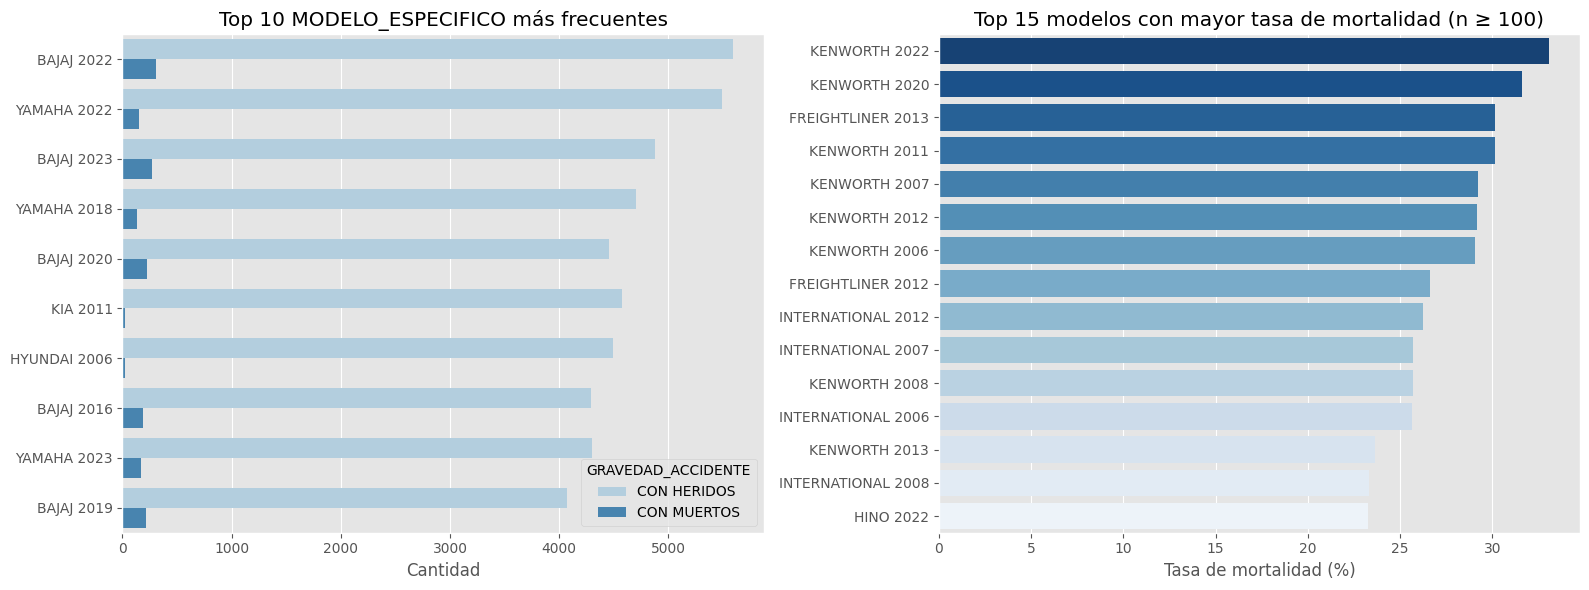

In [102]:
top_modelos = df['MODELO_ESPECIFICO'].value_counts().nlargest(10).index
df_modelos_top = df[df['MODELO_ESPECIFICO'].isin(top_modelos)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 modelos más frecuentes
sns.countplot(data=df_modelos_top, y='MODELO_ESPECIFICO', hue='GRAVEDAD_ACCIDENTE',
              order=top_modelos, palette='Blues', ax=axes[0])
axes[0].set_title('Top 10 MODELO_ESPECIFICO más frecuentes')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('')

# Top 20 modelos con mayor tasa de mortalidad (mínimo 100 registros)
tasa_modelos = df.groupby('MODELO_ESPECIFICO').agg(
    n=('GRAVEDAD_ACCIDENTE', 'count'),
    muertos=('GRAVEDAD_ACCIDENTE', lambda x: (x == 'CON MUERTOS').sum())
)
tasa_modelos['tasa'] = tasa_modelos['muertos'] / tasa_modelos['n'] * 100
top_letales = tasa_modelos[tasa_modelos['n'] >= 100].nlargest(15, 'tasa')

sns.barplot(x=top_letales['tasa'], y=top_letales.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 15 modelos con mayor tasa de mortalidad (n ≥ 100)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 1:**
- Los **vehículos de carga pesada** (volqueta, tractocamión, camión) presentan las tasas de mortalidad más altas, superando ampliamente el promedio global, a pesar de tener frecuencias bajas de accidentalidad.
- Las **motocicletas** son el tipo con mayor volumen absoluto de accidentes, pero su tasa de mortalidad es cercana al promedio global.
- Los **automóviles y camionetas** tienen frecuencias altas pero tasas de mortalidad relativamente bajas, posiblemente por mejores sistemas de seguridad pasiva (airbags, estructura).
- Los **10 modelos más frecuentes** son en su totalidad motocicletas (BAJAJ, YAMAHA, AKT) de años recientes (2018-2023), coherente con el parque de motos en Colombia.
- Los **modelos con mayor tasa de mortalidad** (con al menos 100 registros para garantizar confiabilidad estadística) corresponden a camiones y tractocamiones de marcas como KENWORTH, FREIGHTLINER e INTERNATIONAL, con tasas cercanas al 40%.
- Existe una **paradoja de volumen vs. letalidad**: los modelos más accidentados (motos) no son los más letales, y los más letales (carga pesada) no son los más frecuentes.

### 6.3 Edad del vehículo vs. Gravedad 

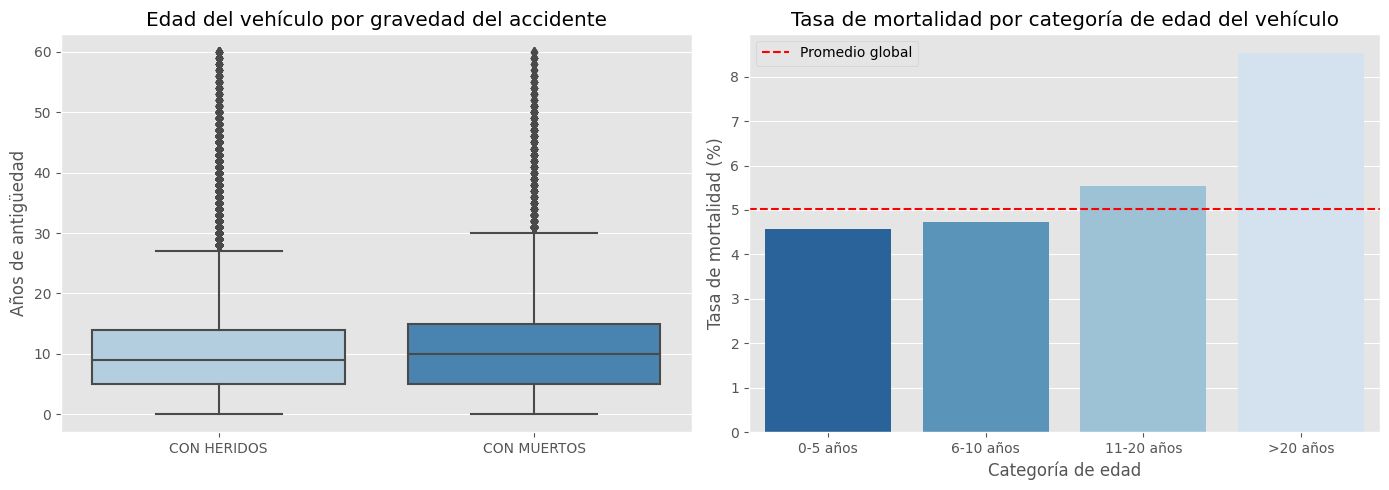

Estadísticas de EDAD_VEHICULO por GRAVEDAD_ACCIDENTE:
                     mean  median   std
GRAVEDAD_ACCIDENTE                     
CON HERIDOS         10.40     9.0  6.98
CON MUERTOS         11.54    10.0  8.55


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: EDAD_VEHICULO por gravedad
sns.boxplot(data=df, x='GRAVEDAD_ACCIDENTE', y='EDAD_VEHICULO',
            palette='Blues', ax=axes[0])
axes[0].set_title('Edad del vehículo por gravedad del accidente')
axes[0].set_xlabel('')
axes[0].set_ylabel('Años de antigüedad')

# Distribución por categoría de edad
tasa_cat = df.groupby('CAT_EDAD_VEHICULO', observed=True)['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reset_index()
tasa_cat.columns = ['Categoría', 'Tasa de mortalidad (%)']

sns.barplot(data=tasa_cat, x='Categoría', y='Tasa de mortalidad (%)',
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Tasa de mortalidad por categoría de edad del vehículo')
axes[1].set_xlabel('Categoría de edad')
axes[1].axhline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por grupo
print("Estadísticas de EDAD_VEHICULO por GRAVEDAD_ACCIDENTE:")
print(df.groupby('GRAVEDAD_ACCIDENTE')['EDAD_VEHICULO'].agg(['mean','median','std']).round(2))

**Hallazgos relacionados con el Objetivo 2:**
- Los vehículos en accidentes **fatales tienen una mediana de edad mayor** (≈11-12 años) que los de accidentes con heridos (≈9-10 años).
- La tasa de mortalidad **aumenta progresivamente con la antigüedad del vehículo**: los vehículos de más de 20 años tienen tasas notablemente superiores al promedio.
- Esto puede atribuirse a menor mantenimiento mecánico, ausencia de sistemas de seguridad modernos (ABS, airbags, asistencia de frenado) y mayor desgaste estructural.

### 6.4 Departamento y autoridad vs. Gravedad 

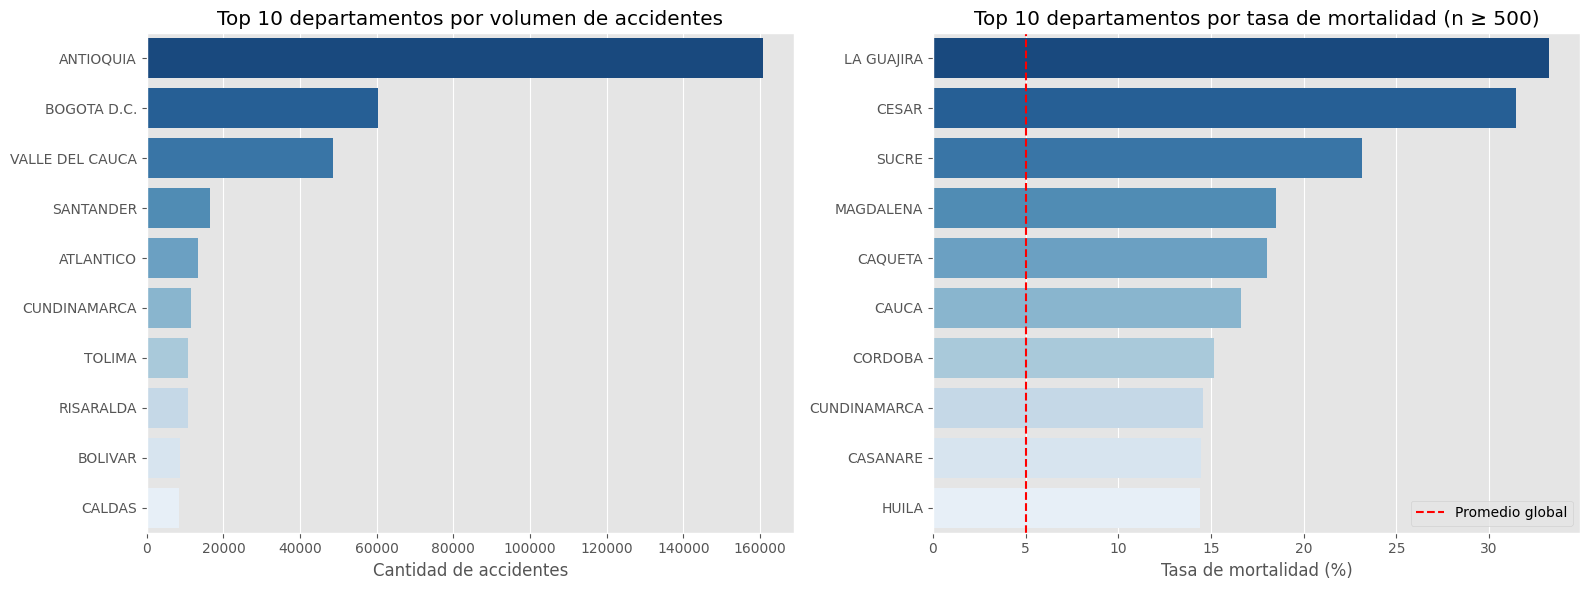

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 departamentos — volumen
top_dep = df['DEPARTAMENTO_ACCIDENTE'].value_counts().nlargest(10)
sns.barplot(x=top_dep.values, y=top_dep.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 departamentos por volumen de accidentes')
axes[0].set_xlabel('Cantidad de accidentes')
axes[0].set_ylabel('')

# Top 10 departamentos — tasa de mortalidad (mínimo 500 registros)
tasa_dep = df.groupby('DEPARTAMENTO_ACCIDENTE').agg(
    n=('GRAVEDAD_ACCIDENTE','count'),
    muertos=('GRAVEDAD_ACCIDENTE', lambda x: (x=='CON MUERTOS').sum())
)
tasa_dep['tasa'] = tasa_dep['muertos'] / tasa_dep['n'] * 100
top_dep_mort = tasa_dep[tasa_dep['n'] >= 500].nlargest(10, 'tasa')

sns.barplot(x=top_dep_mort['tasa'], y=top_dep_mort.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 departamentos por tasa de mortalidad (n ≥ 500)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')
axes[1].axvline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 3 (espacial):**
- **Antioquia, Bogotá y Valle del Cauca** concentran el mayor volumen de accidentes, coherente con su densidad poblacional y actividad vehicular.
- Pero **alta frecuencia ≠ alta mortalidad**: los departamentos periféricos y rurales (como los de la Orinoquía y la Amazonía) presentan las tasas de mortalidad más altas, posiblemente por mayor distancia a centros de atención médica y carreteras de mayor velocidad.
- Este contraste entre **volumen vs. letalidad** es el hallazgo geográfico clave del análisis.

---
## 7. Análisis temporal 

Se analiza la dimensión temporal en cuatro niveles: anual, mensual, por día de la semana y la interacción mes × año.

### 7.1 Evolución anual

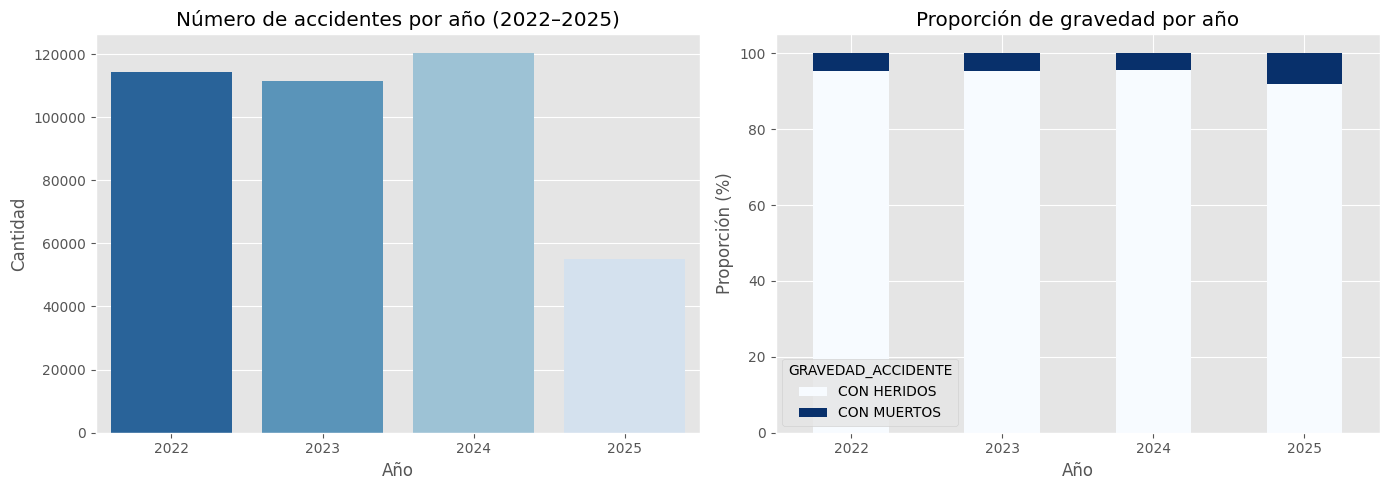

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por año
años_counts = df['AÑO'].value_counts().sort_index()
sns.barplot(x=años_counts.index, y=años_counts.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Número de accidentes por año (2022–2025)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

# Proporción de gravedad por año
tabla_años = pd.crosstab(df['AÑO'], df['GRAVEDAD_ACCIDENTE'], normalize='index') * 100
tabla_años.plot(kind='bar', stacked=True, colormap='Blues', ax=axes[1])
axes[1].set_title('Proporción de gravedad por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Proporción (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 7.2 Estacionalidad mensual

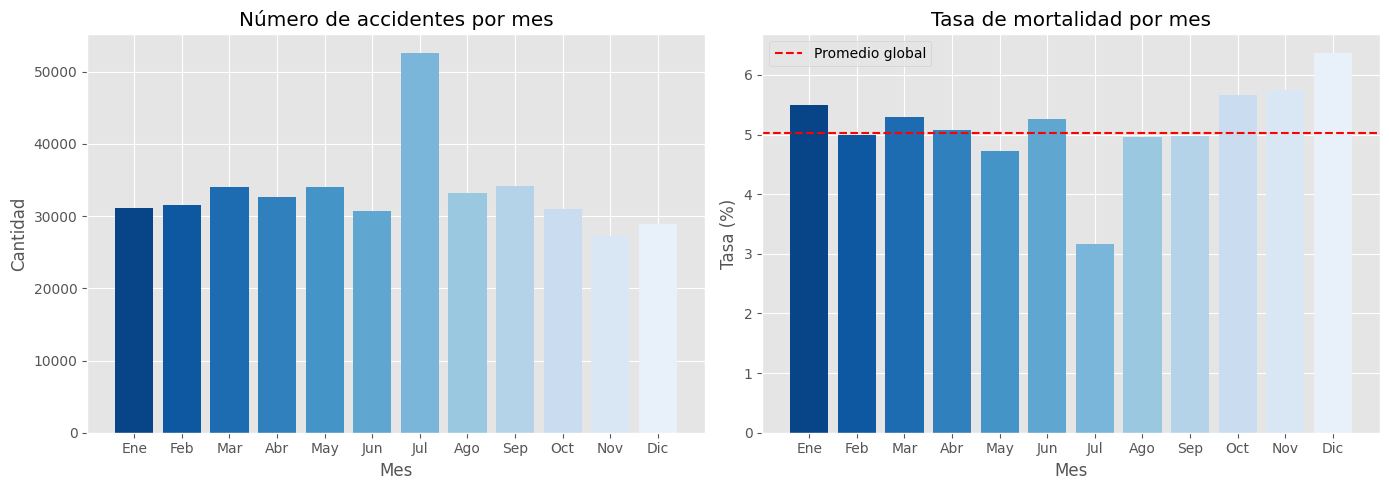

In [106]:
orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
nombres_es  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meses_counts = df['MES_NOMBRE'].value_counts().reindex(orden_meses)
axes[0].bar(nombres_es, meses_counts.values, color=sns.color_palette('Blues_r', 12))
axes[0].set_title('Número de accidentes por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')

tasa_mes = df.groupby('MES_NOMBRE')['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reindex(orden_meses)
axes[1].bar(nombres_es, tasa_mes.values, color=sns.color_palette('Blues_r', 12))
axes[1].axhline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].set_title('Tasa de mortalidad por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Tasa (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.4 Heatmap mes × año y serie de tiempo por tipo de vehículo

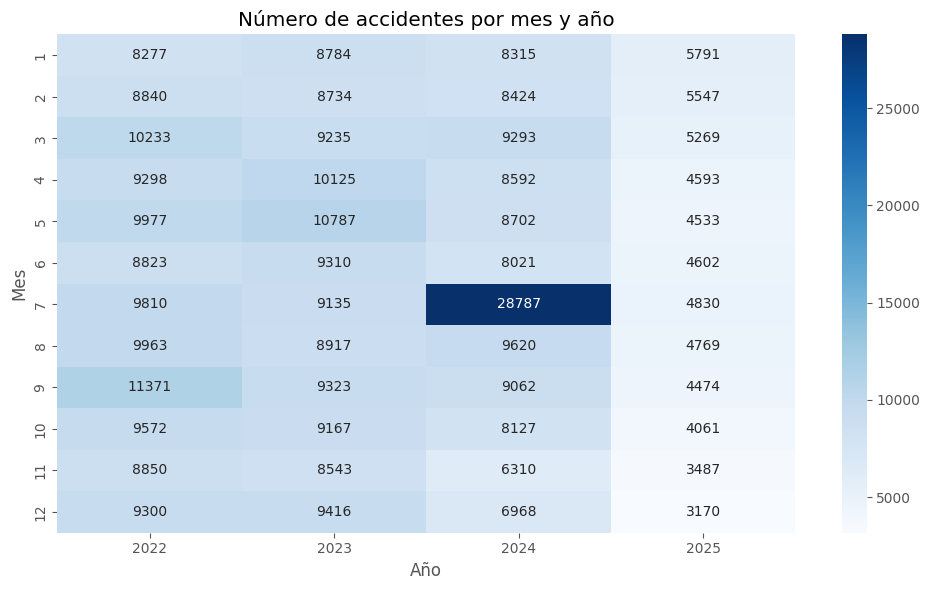

In [109]:
pivot_meses = pd.pivot_table(
    df, values='FECHA_ACCIDENTE', index='MES',
    columns='AÑO', aggfunc='count', fill_value=0
).reindex(range(1, 13))

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_meses, annot=True, fmt='d', cmap='Blues')
plt.title('Número de accidentes por mes y año')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

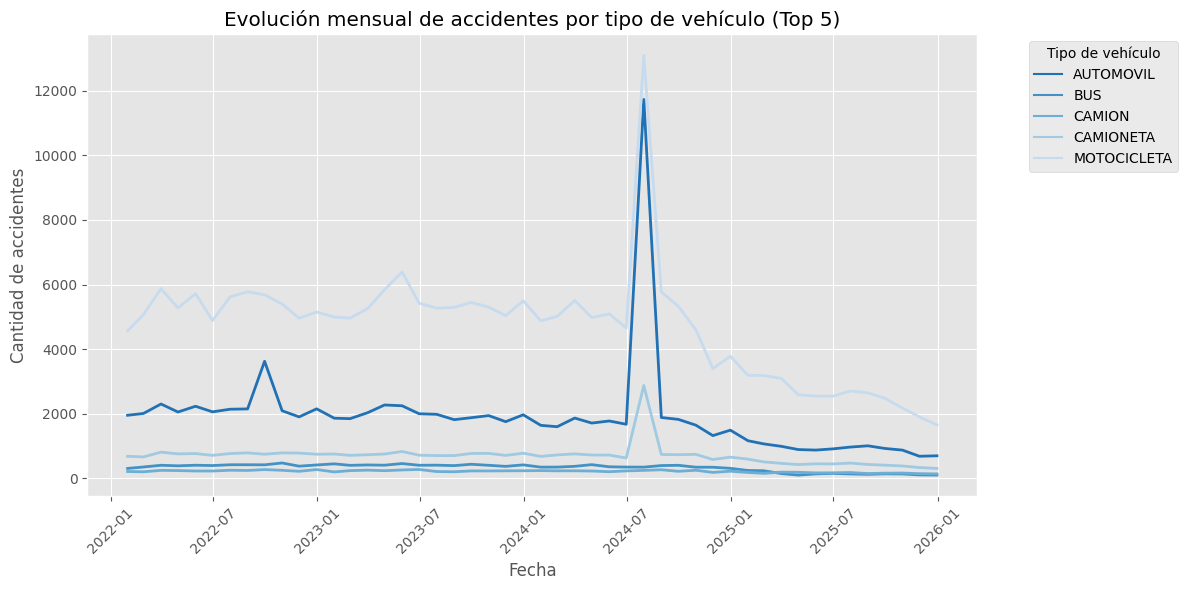

In [110]:
# Serie de tiempo mensual por tipo de vehículo (Top 5)
top5_tipos = df['TIPO_VEHICULO'].value_counts().nlargest(5).index
df_top5 = df[df['TIPO_VEHICULO'].isin(top5_tipos)]

serie = df_top5.groupby([
    pd.Grouper(key='FECHA_ACCIDENTE', freq='ME'),
    'TIPO_VEHICULO'
]).size().reset_index(name='CANTIDAD')

plt.figure(figsize=(12, 6))
colores = sns.color_palette('Blues_r', 7)[1:6]
sns.lineplot(data=serie, x='FECHA_ACCIDENTE', y='CANTIDAD',
             hue='TIPO_VEHICULO', palette=colores, linewidth=2)
plt.title('Evolución mensual de accidentes por tipo de vehículo (Top 5)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de accidentes')
plt.xticks(rotation=45)
plt.legend(title='Tipo de vehículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Aquí se evidencia la anomalía de Julio de 2024.

El 78.7% de los 28,794 registros de julio 2024 provienen de un único reportante
La autoridad en cuestión era la STRIA DE TTOyTTE MEDELLIN, con una tasa de mortalidad que cayó de 4.24% a 1.38%. Se vio que, mientras el volumen se triplicaba, relación inversa incompatible con un fenómeno real.

Concluimos que era de mayor arte un error de carga masiva de registros.

In [111]:
# Filtro Excluir anomalía julio 2024
mascara_anomalia = ~(
    (df['AÑO'] == 2024) &
    (df['MES'] == 7) &
    (df['AUTORIDAD_DE_TRANSITO'] == 'STRIA DE TTOyTTE MEDELLIN')
)
antes = len(df)
df = df[mascara_anomalia]
print(f"Eliminados por anomalía julio 2024: {antes - len(df):,}")
print(f"Dataset final para análisis: {len(df):,} registros")

Eliminados por anomalía julio 2024: 22,667
Dataset final para análisis: 378,470 registros


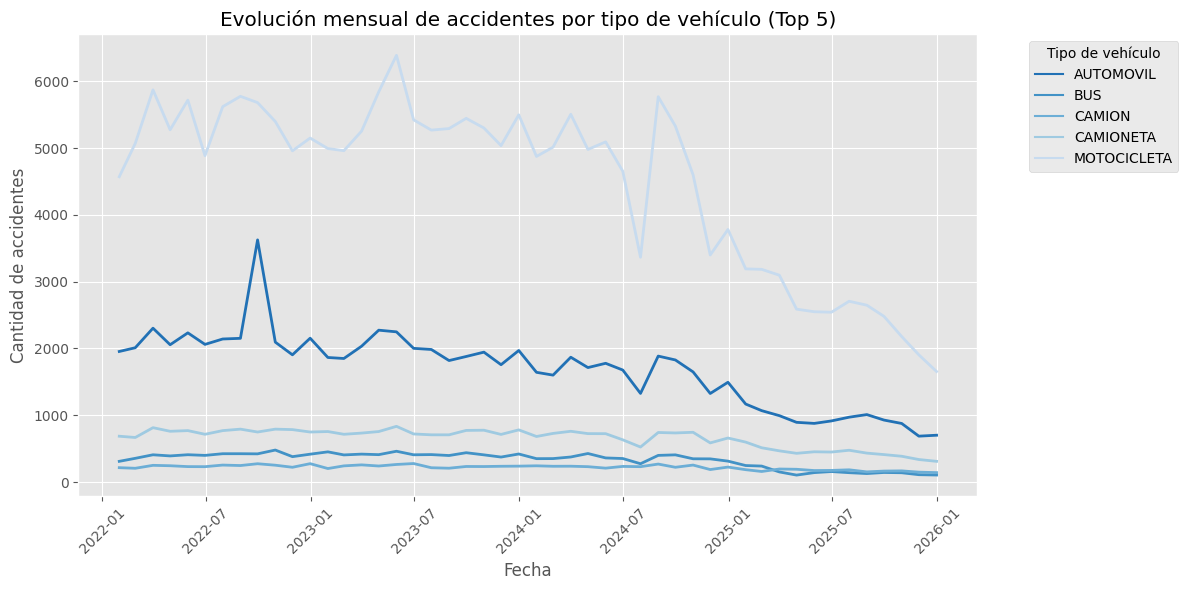

In [113]:
# Serie de tiempo mensual por tipo de vehículo (Top 5)
top5_tipos = df['TIPO_VEHICULO'].value_counts().nlargest(5).index
df_top5 = df[df['TIPO_VEHICULO'].isin(top5_tipos)]

serie = df_top5.groupby([
    pd.Grouper(key='FECHA_ACCIDENTE', freq='ME'),
    'TIPO_VEHICULO'
]).size().reset_index(name='CANTIDAD')

plt.figure(figsize=(12, 6))
colores = sns.color_palette('Blues_r', 7)[1:6]
sns.lineplot(data=serie, x='FECHA_ACCIDENTE', y='CANTIDAD',
             hue='TIPO_VEHICULO', palette=colores, linewidth=2)
plt.title('Evolución mensual de accidentes por tipo de vehículo (Top 5)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de accidentes')
plt.xticks(rotation=45)
plt.legend(title='Tipo de vehículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 3:**
- **Nivel mensual:** Julio es el mes con mayor volumen de accidentes. Meses como marzo y septiembre presentan picos en la tasa de mortalidad, posiblemente asociados a temporadas de lluvia y movilidad recreativa.
- **Nivel semanal:** Los fines de semana (sábado y domingo) concentran una mayor tasa de mortalidad, coherente con el aumento de conducción recreativa y nocturna.
- **Serie de tiempo:** Las motocicletas mantienen un dominio absoluto y estable. Se observan picos recurrentes en julio (vacaciones de mitad de año) y diciembre-enero (temporada navideña).

---
## 8. Análisis geográfico 

Se analizan las diferencias territoriales en volumen de accidentes y tasa de mortalidad, incluyendo el cruce con tipo de vehículo.

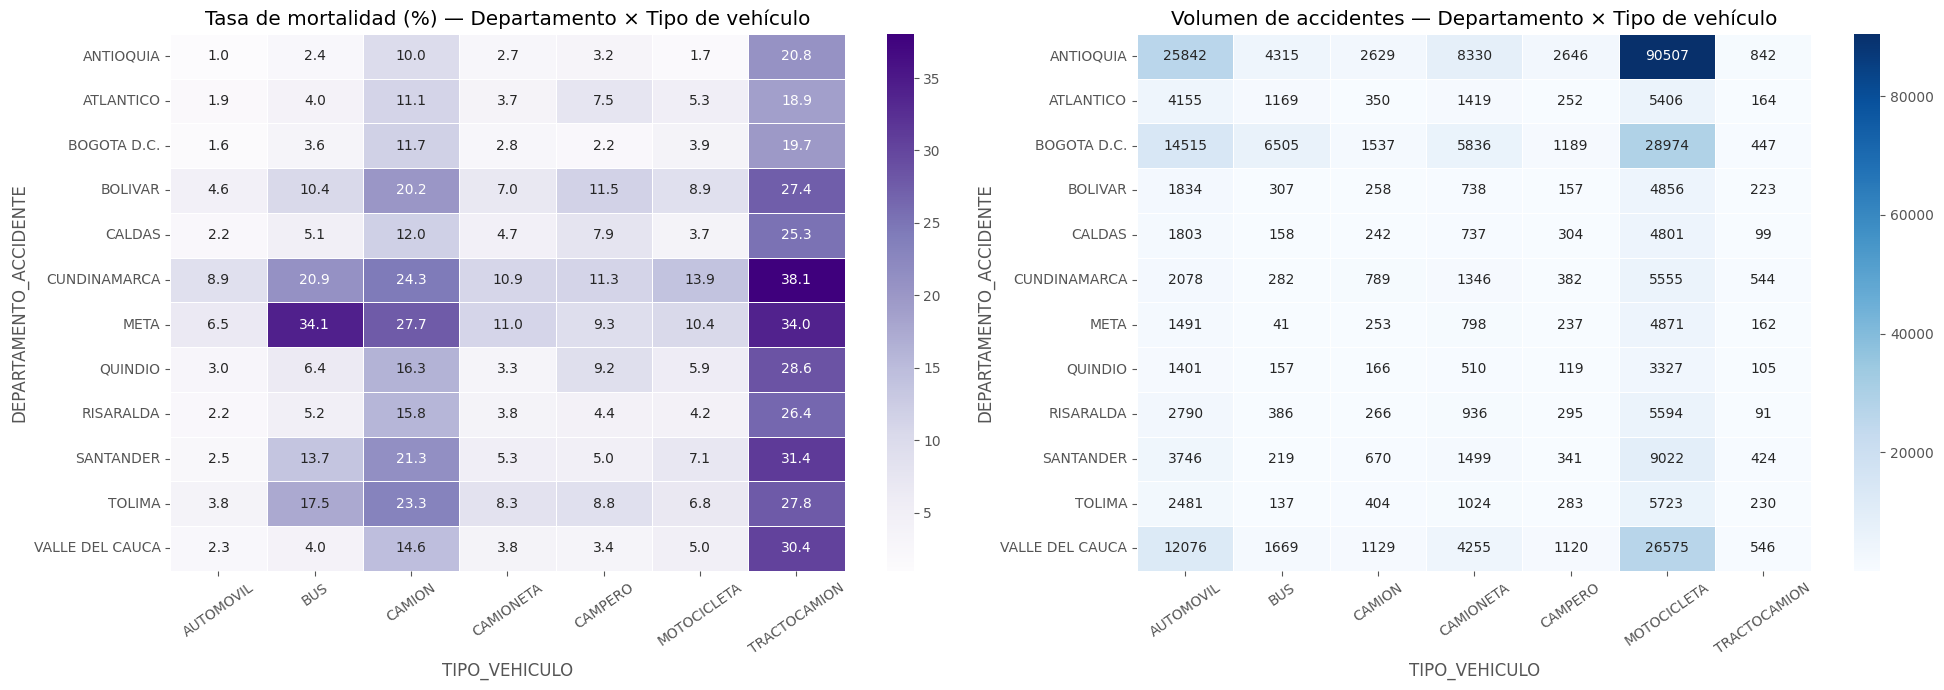

In [112]:
# Heatmap: Tasa de mortalidad y volumen por departamento × tipo de vehículo
top_dep_p2   = df['DEPARTAMENTO_ACCIDENTE'].value_counts().nlargest(12).index
top_tipos_p2 = df['TIPO_VEHICULO'].value_counts().nlargest(7).index

df_cruce = df[
    df['DEPARTAMENTO_ACCIDENTE'].isin(top_dep_p2) &
    df['TIPO_VEHICULO'].isin(top_tipos_p2)
]

pivot_mort = df_cruce.pivot_table(
    index='DEPARTAMENTO_ACCIDENTE', columns='TIPO_VEHICULO',
    values='GRAVEDAD_ACCIDENTE',
    aggfunc=lambda x: (x == 'CON MUERTOS').mean() * 100
)
pivot_cont = df_cruce.pivot_table(
    index='DEPARTAMENTO_ACCIDENTE', columns='TIPO_VEHICULO',
    values='GRAVEDAD_ACCIDENTE', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(pivot_mort, annot=True, fmt='.1f', cmap='Purples', linewidths=0.5, ax=axes[0])
axes[0].set_title('Tasa de mortalidad (%) — Departamento × Tipo de vehículo')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_cont, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[1])
axes[1].set_title('Volumen de accidentes — Departamento × Tipo de vehículo')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

In [160]:
# Mapa interactivo de Colombia (requiere geopandas, folium y shapefile local)
try
    import geopandas as gpd
    import folium
    from folium import GeoJsonPopup
    import unicodedata
    from IPython.display import display

    ruta_shapefile = "C:/Users/maria/OneDrive/Documentos/Seminario/COLOMBIA/COLOMBIA/COLOMBIA.shp"
    colombia_map = gpd.read_file(ruta_shapefile)

    posibles_nombres = ['DPTO_CNMBR','NOMBRE_DPT','DPTO_NOMBRE','DEPARTAMENTO','NOMBRE']
    nombre_col = next((c for c in posibles_nombres if c in colombia_map.columns), colombia_map.columns[0])

    def normalizar(nombre):
        n = str(nombre).upper().strip()
        return ''.join(c for c in unicodedata.normalize('NFD', n) if unicodedata.category(c) != 'Mn')

    accidentes_dep = df.groupby('DEPARTAMENTO_ACCIDENTE').agg(
        TOTAL_ACCIDENTES=('GRAVEDAD_ACCIDENTE','count'),
        TOTAL_MUERTOS=('GRAVEDAD_ACCIDENTE', lambda x: (x=='CON MUERTOS').sum()),
        TASA_MORTALIDAD=('GRAVEDAD_ACCIDENTE', lambda x: (x=='CON MUERTOS').mean()*100)
    ).reset_index()

    accidentes_dep['DEPARTAMENTO_NORM'] = accidentes_dep['DEPARTAMENTO_ACCIDENTE'].apply(normalizar)
    colombia_map['DEPARTAMENTO_NORM']   = colombia_map[nombre_col].apply(normalizar)
    colombia_map = colombia_map.merge(accidentes_dep, on='DEPARTAMENTO_NORM', how='left')
    colombia_map['TOTAL_ACCIDENTES']    = colombia_map['TOTAL_ACCIDENTES'].fillna(0)
    colombia_map['TASA_MORTALIDAD']     = colombia_map['TASA_MORTALIDAD'].fillna(0)

    m = folium.Map(location=[4.5709, -74.2973], zoom_start=6, tiles='CartoDB positron')

    folium.Choropleth(
        geo_data=colombia_map, name='Accidentes', data=colombia_map,
        columns=['DEPARTAMENTO_NORM','TOTAL_ACCIDENTES'], key_on='feature.properties.DEPARTAMENTO_NORM',
        fill_color='Blues', fill_opacity=0.7, line_opacity=0.2,
        legend_name='Número de Accidentes'
    ).add_to(m)

    folium.Choropleth(
        geo_data=colombia_map, name='Mortalidad (%)', data=colombia_map,
        columns=['DEPARTAMENTO_NORM','TASA_MORTALIDAD'], key_on='feature.properties.DEPARTAMENTO_NORM',
        fill_color='PuBu', fill_opacity=0.7, line_opacity=0.2,
        legend_name='Tasa de Mortalidad (%)'
    ).add_to(m)

    popup = GeoJsonPopup(
        fields=[nombre_col,'TOTAL_ACCIDENTES','TASA_MORTALIDAD'],
        aliases=['Departamento:','Accidentes:','Tasa Mortalidad (%):'],
        localize=True, labels=True
    )
    folium.GeoJson(
        colombia_map, name='Información',
        style_function=lambda x: {'fillOpacity': 0, 'weight': 0.5, 'color': 'gray'},
        popup=popup
    ).add_to(m)

    folium.Marker([4.5709, -74.2973], popup='Bogotá D.C.',
                  icon=folium.Icon(color='red', icon='info-sign', prefix='fa')).add_to(m)
    folium.LayerControl().add_to(m)
    m.save('mapa_accidentalidad_colombia.html')
    print("Mapa guardado como 'mapa_accidentalidad_colombia.html'")
    display(m)

except Exception as e:
    print(f"Mapa interactivo no disponible en este entorno: {e}")
    print("El análisis geográfico se sustenta en el heatmap y los gráficos de barras anteriores.")

SyntaxError: invalid syntax (3760148488.py, line 2)

---
## 9. Análisis inferencial

Se aplican pruebas estadísticas formales para validar las tendencias observadas en las secciones anteriores.

### 9.1 Normalidad KS

In [114]:
from scipy.stats import kstest

data = df['EDAD_VEHICULO']

stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))

print(f"Estadístico: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico: 0.1086
p-valor: 0.0000


Al no ser normal por tener un p valor < 0.05, entonces aplicamos Mann-Whitney pues funciona bien con datos sesgados y amplios.

In [117]:
from scipy.stats import mannwhitneyu

grupo1 = df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO']
grupo2 = df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO']

stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print(f"Estadístico U: {stat}")
print(f"p-valor: {p:.4f}")

Estadístico U: 3350130080.0
p-valor: 0.0000


In [120]:
heridos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO'].dropna()
muertos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO'].dropna()

stat, p = stats.mannwhitneyu(heridos, muertos, alternative='two-sided')
print(f"Mann-Whitney U")
print(f"  stat={stat:.2f}, p={p:.2e}")
print(f"  → {'Diferencia significativa' if p < 0.05 else 'Sin diferencia'}")

Mann-Whitney U
  stat=3350130080.00, p=1.13e-65
  → Diferencia significativa


### 9.2 Relación de EDAD_VEHICULO y TIPO DE VEHÍCULO

Primero revisamos con cuál grupo exactamente hacer la prueba. Los valores con menos reproducción no son necesarios. Por ello, hacemos un filtro para especificar cuáles usar y evitar. Una cifra inicial elegimos los mayores de 100.

In [122]:
df['TIPO_VEHICULO'].value_counts()

TIPO_VEHICULO
MOTOCICLETA        215807
AUTOMOVIL           81209
CAMIONETA           31525
BUS                 15928
CAMION              10543
CAMPERO              8430
TRACTOCAMION         4972
MICROBUS             4287
BUSETA               2806
VOLQUETA             1863
MOTOCARRO             856
CICLOMOTOR            140
CUATRIMOTO             25
CUADRICICLO            20
TRACTOR                16
MAQ. AGRICOLA           9
MONTACARGAS             8
RETROEXCAVADORA         5
MAQ. INDUSTRIAL         3
REMOLQUE                3
MINICARGADOR            3
CARGADOR                3
FRESADORA               2
SEMIREMOLQUE            2
EXCAVADORA              2
MOTONIVELADORA          1
COMPACTADOR             1
PAVIMENTADORA           1
Name: count, dtype: int64

In [ ]:
from scipy import stats

# Filtrar tipos con suficiente tamaño
conteo = df['TIPO_VEHICULO'].value_counts()
tipos_validos = conteo[conteo >= 30].index

# Crear grupos
grupos = [
    df[df['TIPO_VEHICULO'] == tipo]['EDAD_VEHICULO'].dropna()
    for tipo in tipos_validos
]

# Prueba
stat, p = stats.kruskal(*grupos)

print("Kruskal-Wallis — EDAD_VEHICULO entre tipos de vehículo")
print(f"H = {stat:.2f}, p = {p:.4e}")

if p < 0.05:
    print("Existen diferencias significativas entre tipos de vehículo")
else:
    print("No se encontraron diferencias significativas")

Kruskal-Wallis — EDAD_VEHICULO entre tipos de vehículo
H = 57946.72, p = 0.0000e+00
→ Existen diferencias significativas entre tipos de vehículo


In [ ]:
grupos = [
    df[df['TIPO_VEHICULO'] == tipo]['EDAD_VEHICULO'].dropna()
    for tipo in df['TIPO_VEHICULO'].value_counts().nlargest(8).index
]

stat, p = stats.kruskal(*grupos)
print(f"Kruskal-Wallis")
print(f"  H={stat:.2f}, p={p:.2e}")
print(f"  → {'Diferencias significativas entre tipos' if p < 0.05 else 'Sin diferencias'}")

Kruskal-Wallis — EDAD_VEHICULO entre tipos de vehículo
  H=53298.33, p=0.00e+00
  → Diferencias significativas entre tipos


### 9.3 Categóricas vs GRAVEDAD

Mismo caso con la marca del vehículo, elegimos el top 10 pues hay muchas categoricas y algunas de muy baja frecuencia, por lo cual usamos el top 10 con las mayores cantidades, y las de baja frecuencia las agrupamos en la categoría OTROS. Así no se rompe el supuesto para el uso de Chi-cuadrado, el cual dice que debe tener frecuencias esperadas >= 5.

In [125]:
# Top N marcas (ajusta N si quieres)
top_n = 10
top_marcas = df['MARCA_VEHICULO'].value_counts().nlargest(top_n).index

df['MARCA_AGRUPADA'] = df['MARCA_VEHICULO'].apply(
    lambda x: x if x in top_marcas else 'OTROS'
)

In [126]:
df['MARCA_AGRUPADA'].value_counts()

MARCA_AGRUPADA
OTROS        101220
BAJAJ         50501
YAMAHA        45071
CHEVROLET     44246
AKT           30846
HONDA         24178
SUZUKI        21830
RENAULT       19417
HYUNDAI       15673
KIA           14134
TVS           11354
Name: count, dtype: int64

In [127]:
def cramer_v(df, var, objetivo='GRAVEDAD_ACCIDENTE'):
    tabla = pd.crosstab(df[var], df[objetivo])
    
    chi2, p, dof, expected = ss.chi2_contingency(tabla)
    
    n = tabla.sum().sum()
    r, k = tabla.shape
    
    v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    
    return chi2, p, v, tabla, expected

In [135]:
variables = ['TIPO_VEHICULO', 'MARCA_AGRUPADA', 'MUNICIPIO_ACCIDENTE']

for var in variables:
    chi2, p, v, tabla, expected = cramer_v(df, var)
    
    # Interpretación de fuerza
    if v < 0.10:
        fuerza = 'Muy débil'
    elif v < 0.20:
        fuerza = 'Débil'
    elif v < 0.40:
        fuerza = 'Moderada'
    else:
        fuerza = 'Fuerte'
    
    print(f"\nVariable: {var}")
    print(f"Chi² = {chi2:.1f}")
    print(f"p-valor = {p:.2e}")
    print(f"V de Cramér = {v:.4f} ({fuerza})")


Variable: TIPO_VEHICULO
Chi² = 10656.1
p-valor = 0.00e+00
V de Cramér = 0.1678 (Débil)

Variable: MARCA_AGRUPADA
Chi² = 1241.5
p-valor = 1.62e-260
V de Cramér = 0.0573 (Muy débil)

Variable: MUNICIPIO_ACCIDENTE
Chi² = 39804.8
p-valor = 0.00e+00
V de Cramér = 0.3243 (Moderada)


Posteriormente, se evaluó la relación entre variables categóricas mediante chi-cuadrado y el coeficiente V de Cramér, permitiendo analizar tanto la significancia estadística como la fuerza de asociación.

In [136]:
def evaluar_asociacion(df, variable_objetivo, excluir=None):
    
    if excluir is None:
        excluir = []
    
    resultados = []
    
    cols = [
        c for c in df.select_dtypes(include=['object','category']).columns
        if c != variable_objetivo and c not in excluir
    ]
    
    for col in cols:
        tabla = pd.crosstab(df[col], df[variable_objetivo])
        
        # Validar que la tabla sea válida
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
        
        chi2, _, _, _ = ss.chi2_contingency(tabla)
        
        n = tabla.sum().sum()
        r, k = tabla.shape
        
        v = np.sqrt(chi2 / (n * min(r-1, k-1))) if min(r-1, k-1) > 0 else 0
        
        # Interpretación
        if v < 0.10:
            fuerza = 'Muy débil'
        elif v < 0.20:
            fuerza = 'Débil'
        elif v < 0.40:
            fuerza = 'Moderada'
        else:
            fuerza = 'Fuerte'
        
        resultados.append({
            'Variable': col,
            'V_de_Cramer': round(v, 4),
            'Asociación': fuerza
        })
    
    return pd.DataFrame(resultados)\
             .sort_values('V_de_Cramer', ascending=False)\
             .reset_index(drop=True)

In [138]:
tabla_v = evaluar_asociacion(
    df,
    'GRAVEDAD_ACCIDENTE',
    excluir=['TIPO_VEHICULO', 'MARCA_VEHICULO', 'MARCA_AGRUPADA', 'MUNICIPIO_ACCIDENTE', 'ID_REGISTRO']
)

print("Asociación de variables categóricas restantes con GRAVEDAD_ACCIDENTE:")
print(tabla_v.to_string(index=False))

Asociación de variables categóricas restantes con GRAVEDAD_ACCIDENTE:
              Variable  V_de_Cramer Asociación
 AUTORIDAD_DE_TRANSITO       0.3229   Moderada
DEPARTAMENTO_ACCIDENTE       0.2110   Moderada
     MODELO_ESPECIFICO       0.1933      Débil
     CAT_EDAD_VEHICULO       0.0469  Muy débil
            MES_NOMBRE       0.0189  Muy débil
            DIA_SEMANA       0.0097  Muy débil


`AUTORIDAD_DE_TRANSITO`y `DEPARTAMENTO_ACCIDENTE` presentan la asociación moderada, lo que confirma que la geografía específica del siniestro es el predictor más fuerte.
`MES_NOMBRE`, `MODELO_ESPECIFICO`, `CAT_EDAD`, `DIA_SEMANA` tienen asociación muy débil: por sí solos no predicen bien la gravedad.

### 9.3 Test de proporciones con intervalos de confianza Wilson 

Se evalúan diferencias en tasas de mortalidad entre grupos, con **filtros de confiabilidad estadística** para garantizar que los grupos analizados tengan suficiente tamaño muestral.

> **Parámetros de confiabilidad**:
> - `muestra_mínima = 100` → SE ≤ 2.17% 
> - `eventos_mínimos = 10` → regla n×p ≥ 10 
> - `ancho_IC_máximo = 20%` → límite de utilidad práctica 

In [140]:
def wilson_ic(n, x, z=1.96):
    """Intervalo de confianza de Wilson para proporciones."""
    if n == 0: return 0, 0, 0
    p = x / n
    if x == 0:
        ic_sup = min(1, 3/n)
        return 0, ic_sup, ic_sup * 100
    if x == n:
        ic_inf = max(0, 1 - 3/n)
        return ic_inf, 1, (1 - ic_inf) * 100
    den = 1 + z**2/n
    centro = (p + z**2/(2*n)) / den
    margen = z * np.sqrt((p*(1-p) + z**2/(4*n))/n) / den
    ic_inf = max(0, centro - margen)
    ic_sup = min(1, centro + margen)
    return ic_inf, ic_sup, (ic_sup - ic_inf) * 100


def test_proporciones_confiable(df, columna_grupo, columna_evento='GRAVEDAD_ACCIDENTE',
                                 categoria='CON MUERTOS',
                                 muestra_minima=100, eventos_minimos=10, ancho_ic_max=20,
                                 titulo=''):
    """Test Z de proporciones con filtros de confiabilidad estadística."""
    print(f"\n{'='*80}")
    print(f"TEST DE PROPORCIONES: {categoria} por {columna_grupo} {titulo}")
    print(f"{'='*80}")

    df_t = df.dropna(subset=[columna_grupo, columna_evento]).copy()
    tabla = pd.crosstab(df_t[columna_grupo], df_t[columna_evento])
    if categoria not in tabla.columns:
        print("ERROR: categoría no encontrada."); return None
    tabla['TOTAL'] = tabla.sum(axis=1)

    confiables, no_confiables, metricas = [], [], []
    for g in tabla.index:
        n, x = int(tabla.loc[g,'TOTAL']), int(tabla.loc[g, categoria])
        ic_inf, ic_sup, ancho = wilson_ic(n, x)
        ok = (n >= muestra_minima) and (x >= eventos_minimos) and ((n-x) >= eventos_minimos) and (ancho <= ancho_ic_max)
        metricas.append({'Grupo': g, 'n': n, 'eventos': x, 'tasa_%': round(x/n*100,2) if n>0 else 0,
                         'IC_inf_%': round(ic_inf*100,2), 'IC_sup_%': round(ic_sup*100,2),
                         'Ancho_IC': round(ancho,2), 'Confiable': ok})
        (confiables if ok else no_confiables).append(g)

    df_m = pd.DataFrame(metricas)
    print(f"\nGrupos confiables: {len(confiables)} / {len(metricas)} totales")
    print(f"(Criterios: n≥{muestra_minima}, eventos≥{eventos_minimos}, Ancho IC≤{ancho_ic_max}%)")
    print()
    print(df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False).to_string(index=False))

    if len(confiables) < 2:
        print("Insuficientes grupos confiables para comparar."); return None

    # Ranking visual
    print(f"\nRANKING (grupos confiables):")
    for i, (_, row) in enumerate(df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False).iterrows(), 1):
        barra = '█' * int(row['tasa_%'] * 3)
        print(f"  {i:2}. {str(row['Grupo'])[:30]:<31} {row['tasa_%']:6.2f}%  {barra}")

    # Gráfico
    df_plot = df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False)
    plt.figure(figsize=(10, 0.5 + 0.5 * len(df_plot)))
    plt.barh(df_plot['Grupo'], df_plot['tasa_%'], color=sns.color_palette('Blues_r', len(df_plot)))
    plt.errorbar(
        df_plot['tasa_%'], range(len(df_plot)),
        xerr=[(df_plot['tasa_%'] - df_plot['IC_inf_%']).values,
              (df_plot['IC_sup_%'] - df_plot['tasa_%']).values],
        fmt='none', color='black', capsize=4
    )
    global_rate = df[df[columna_evento].notna()][columna_evento].eq(categoria).mean() * 100
    plt.axvline(global_rate, color='red', linestyle='--', label=f'Global ({global_rate:.2f}%)')
    plt.gca().invert_yaxis()
    plt.title(f'Tasa de mortalidad con IC 95% por {columna_grupo} {titulo}')
    plt.xlabel('Tasa de mortalidad (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_m


TEST DE PROPORCIONES: CON MUERTOS por TIPO_VEHICULO — Objetivo 1

Grupos confiables: 11 / 28 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

       Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
TRACTOCAMION   4972     1436   28.88     27.64     30.16      2.52       True
    VOLQUETA   1863      369   19.81     18.06     21.68      3.62       True
      CAMION  10543     1858   17.62     16.91     18.36      1.45       True
    MICROBUS   4287      258    6.02      5.34      6.77      1.43       True
     CAMPERO   8430      496    5.88      5.40      6.41      1.01       True
   MOTOCARRO    856       50    5.84      4.46      7.62      3.16       True
   CAMIONETA  31525     1672    5.30      5.06      5.56      0.49       True
         BUS  15928      828    5.20      4.86      5.55      0.69       True
      BUSETA   2806      141    5.02      4.28      5.90      1.62       True
 MOTOCICLETA 215807    10792    5.00      4.91      5.09      0.18      

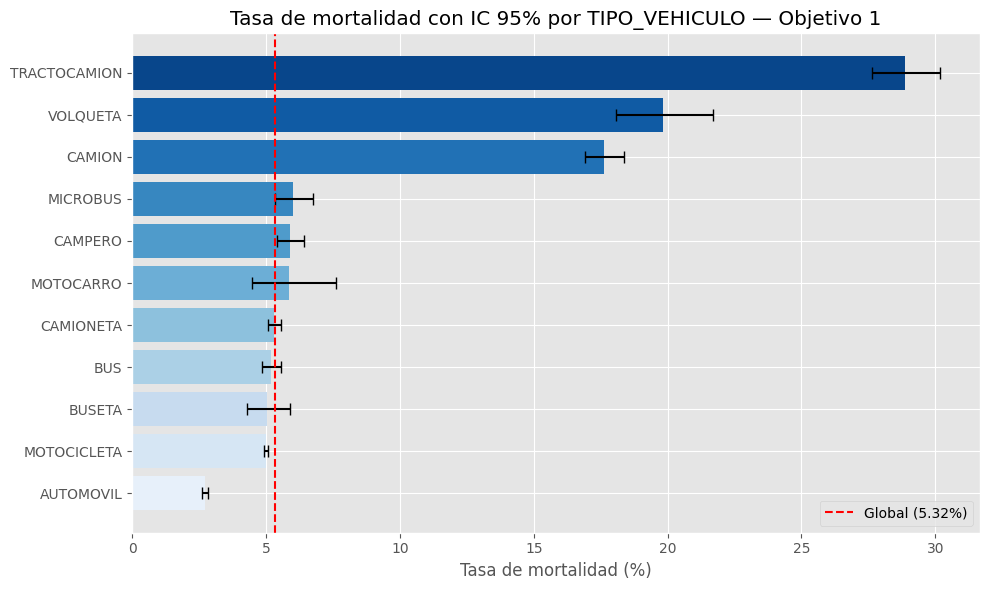

In [141]:
# Objetivo 1: Tipo de vehículo
resultado_tipo = test_proporciones_confiable(
    df, columna_grupo='TIPO_VEHICULO',
    titulo='— Objetivo 1'
)


TEST DE PROPORCIONES: CON MUERTOS por MARCA_VEHICULO — Objetivo 1

Grupos confiables: 65 / 356 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

             Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
      FREIGHTLINER   657      189   28.77     25.44     32.34      6.91       True
          KENWORTH  2606      707   27.13     25.46     28.87      3.41       True
     INTERNATIONAL  2841      631   22.21     20.72     23.78      3.06       True
               DAF   181       39   21.55     16.18     28.09     11.91       True
              MACK   133       28   21.05     14.99     28.74     13.76       True
   MITSUBISHI FUSO   136       25   18.38     12.77     25.73     12.96       True
             DODGE   967      157   16.24     14.05     18.69      4.65       True
            KEEWAY   166       24   14.46      9.91     20.61     10.70       True
               JAC  1528      194   12.70     11.12     14.46      3.34       True
             FOTON  

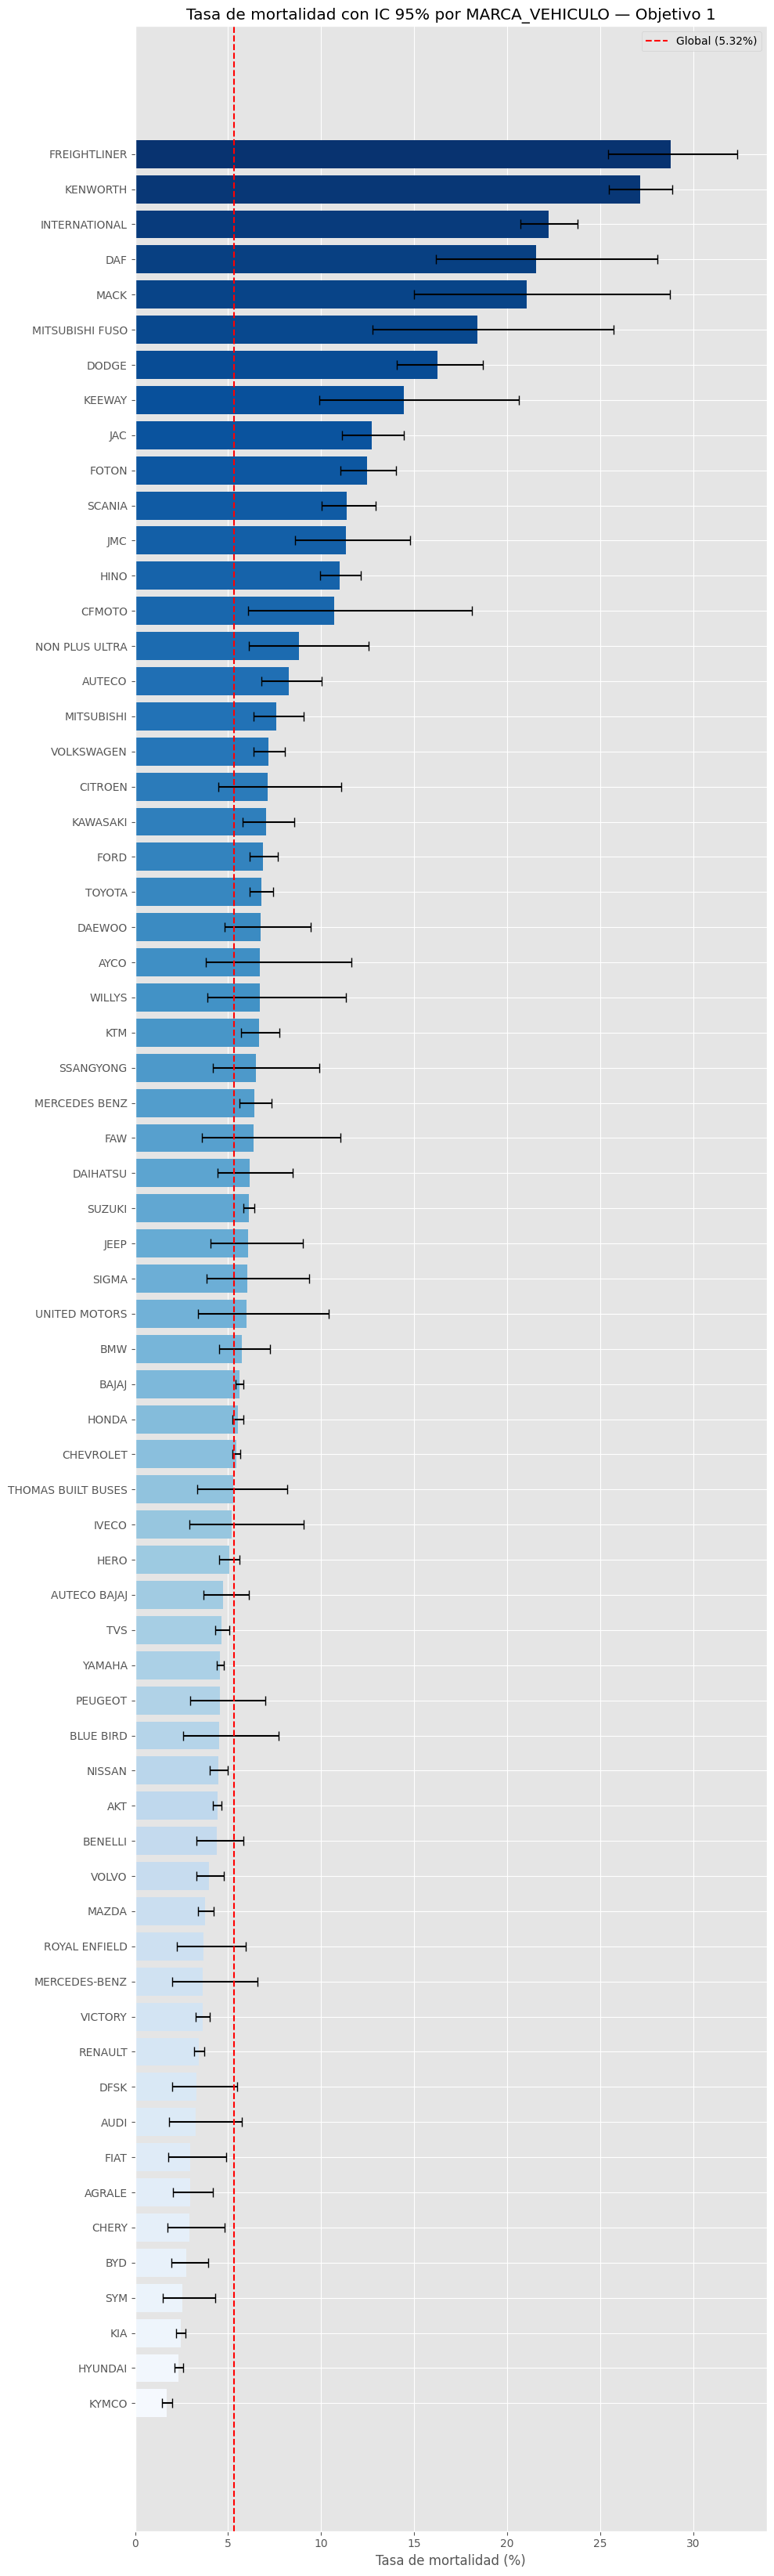

In [142]:
# Objetivo 1: Marca de vehículo
resultado_marca = test_proporciones_confiable(
    df, columna_grupo='MARCA_VEHICULO',
    titulo='— Objetivo 1'
)

Encontramos que los vehículos de carga pesada (tractocamión, volqueta, camión) presentan tasas de mortalidad que superan entre 3 y 6 veces el promedio global (~5%). Sus intervalos de confianza al 95% no se solapan con los de motocicletas ni automóviles,
lo que indica que la diferencia no es atribuible al azar.

Mientras que las motocicletas, teniendo un  mayor volumen absoluto de accidentes, presentan una tasa de mortalidad cercana al promedio global. Esto muestra que a mayor frecuencia de accidentes no implica mayor probabilidad de un desenlace fatal por evento.

El automóvil y la camioneta muestran las tasas más bajas del ranking, coherente con la presencia de sistemas de seguridad como airbags o estructura de absorción de impacto, que nos los tienen los vehículos de dos ruedas y en la carga pesada más antigua.

Al haber casos donde no se diferencia la cifra de aumento de marca de vehículo con el tipo de vehiculo, hacemos un pruebas para filtar entre ambos tops las marcas y tipos diferenciados.


TIPO DE VEHÍCULO: MOTOCICLETA

--- ANÁLISIS: CON MUERTOS ---

TEST DE PROPORCIONES: CON MUERTOS por MARCA_AGRUPADA (dentro de MOTOCICLETA)

Grupos confiables: 7 / 8 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

 Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
SUZUKI 19249     1271    6.60      6.26      6.96      0.70       True
 BAJAJ 50248     2814    5.60      5.40      5.80      0.40       True
 HONDA 23485     1310    5.58      5.29      5.88      0.59       True
   TVS 11307      526    4.65      4.28      5.06      0.78       True
YAMAHA 45060     2059    4.57      4.38      4.77      0.39       True
   AKT 30630     1349    4.40      4.18      4.64      0.46       True
 OTROS 35826     1463    4.08      3.88      4.29      0.41       True

RANKING (grupos confiables):
   1. SUZUKI                            6.60%  ███████████████████
   2. BAJAJ                             5.60%  ████████████████
   3. HONDA                             5.58%  ████

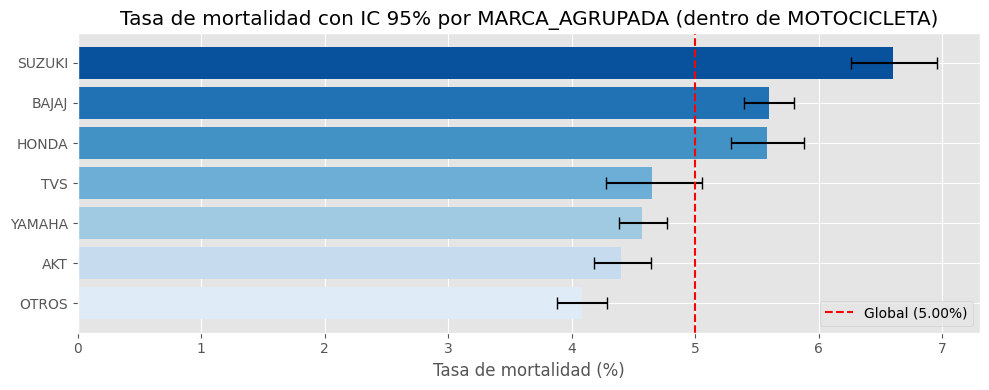


--- ANÁLISIS: CON HERIDOS ---

TEST DE PROPORCIONES: CON HERIDOS por MARCA_AGRUPADA (dentro de MOTOCICLETA)

Grupos confiables: 7 / 8 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

 Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
 OTROS 35826    34363   95.92     95.71     96.12      0.41       True
   AKT 30630    29281   95.60     95.36     95.82      0.46       True
YAMAHA 45060    43001   95.43     95.23     95.62      0.39       True
   TVS 11307    10781   95.35     94.94     95.72      0.78       True
 HONDA 23485    22175   94.42     94.12     94.71      0.59       True
 BAJAJ 50248    47434   94.40     94.20     94.60      0.40       True
SUZUKI 19249    17978   93.40     93.04     93.74      0.70       True

RANKING (grupos confiables):
   1. OTROS                            95.92%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

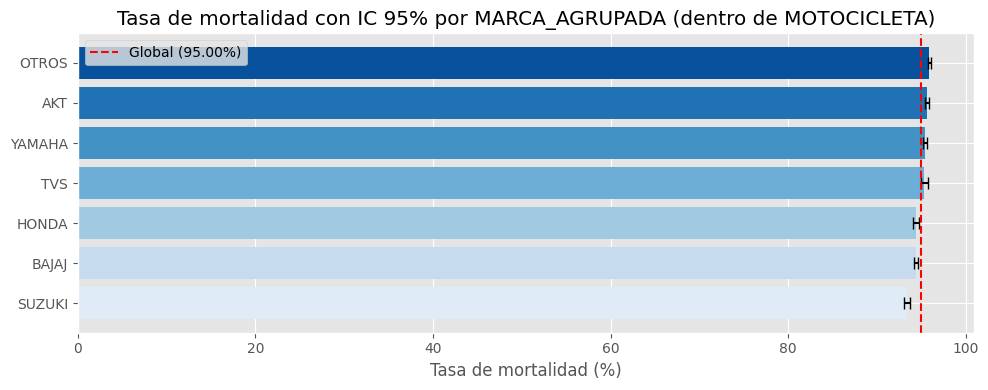


TIPO DE VEHÍCULO: AUTOMOVIL

--- ANÁLISIS: CON MUERTOS ---

TEST DE PROPORCIONES: CON MUERTOS por MARCA_AGRUPADA (dentro de AUTOMOVIL)

Grupos confiables: 6 / 7 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
    OTROS 15678      560    3.57      3.29      3.87      0.58       True
  RENAULT 14697      482    3.28      3.00      3.58      0.58       True
CHEVROLET 23248      669    2.88      2.67      3.10      0.43       True
      KIA 11984      222    1.85      1.63      2.11      0.48       True
   SUZUKI  1577       29    1.84      1.28      2.63      1.35       True
  HYUNDAI 13832      249    1.80      1.59      2.04      0.44       True

RANKING (grupos confiables):
   1. OTROS                             3.57%  ██████████
   2. RENAULT                           3.28%  █████████
   3. CHEVROLET                         2.88%  ████████
   4. KIA                               1.85%  █████
   5. SUZUKI

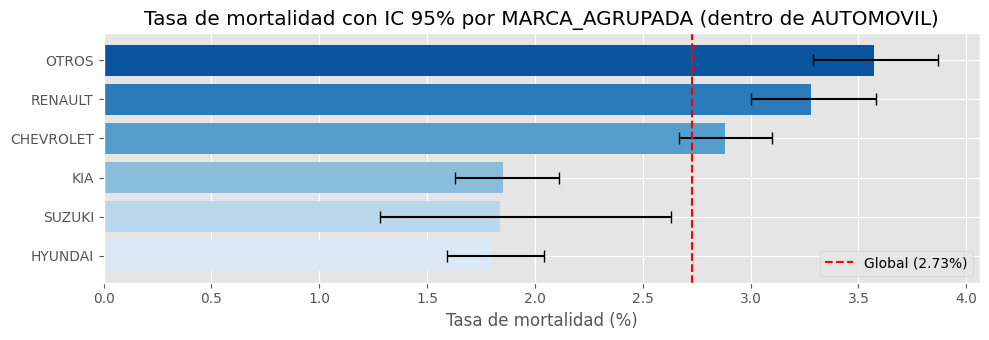


--- ANÁLISIS: CON HERIDOS ---

TEST DE PROPORCIONES: CON HERIDOS por MARCA_AGRUPADA (dentro de AUTOMOVIL)

Grupos confiables: 6 / 7 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  HYUNDAI 13832    13583   98.20     97.96     98.41      0.44       True
   SUZUKI  1577     1548   98.16     97.37     98.72      1.35       True
      KIA 11984    11762   98.15     97.89     98.37      0.48       True
CHEVROLET 23248    22579   97.12     96.90     97.33      0.43       True
  RENAULT 14697    14215   96.72     96.42     97.00      0.58       True
    OTROS 15678    15118   96.43     96.13     96.71      0.58       True

RANKING (grupos confiables):
   1. HYUNDAI                          98.20%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

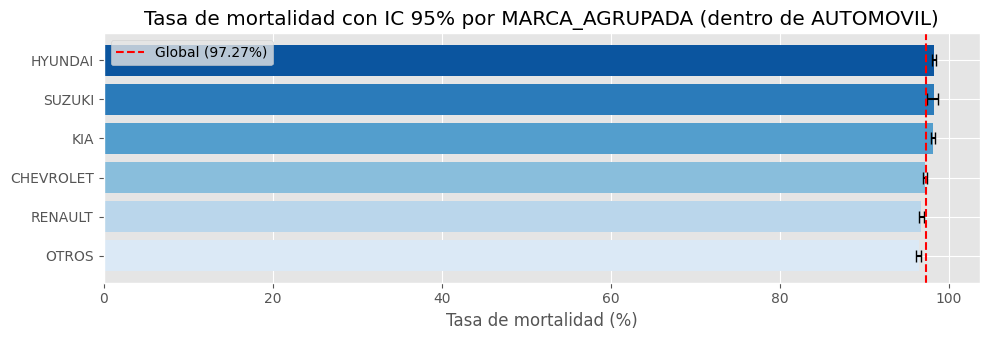


TIPO DE VEHÍCULO: CAMIONETA

--- ANÁLISIS: CON MUERTOS ---

TEST DE PROPORCIONES: CON MUERTOS por MARCA_AGRUPADA (dentro de CAMIONETA)

Grupos confiables: 6 / 7 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  HYUNDAI   973       63    6.47      5.09      8.20      3.11       True
      KIA  1518       92    6.06      4.97      7.38      2.41       True
    OTROS 17810      985    5.53      5.20      5.88      0.67       True
CHEVROLET  6871      378    5.50      4.99      6.07      1.08       True
  RENAULT  3484      133    3.82      3.23      4.51      1.28       True
   SUZUKI   575       15    2.61      1.59      4.26      2.67       True

RANKING (grupos confiables):
   1. HYUNDAI                           6.47%  ███████████████████
   2. KIA                               6.06%  ██████████████████
   3. OTROS                             5.53%  ████████████████
   4. CHEVROLET                        

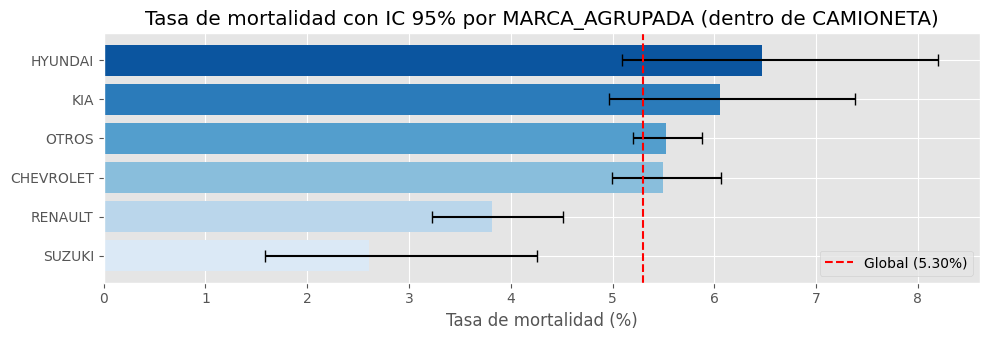


--- ANÁLISIS: CON HERIDOS ---

TEST DE PROPORCIONES: CON HERIDOS por MARCA_AGRUPADA (dentro de CAMIONETA)

Grupos confiables: 6 / 7 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
   SUZUKI   575      560   97.39     95.74     98.41      2.67       True
  RENAULT  3484     3351   96.18     95.49     96.77      1.28       True
CHEVROLET  6871     6493   94.50     93.93     95.01      1.08       True
    OTROS 17810    16825   94.47     94.12     94.80      0.67       True
      KIA  1518     1426   93.94     92.62     95.03      2.41       True
  HYUNDAI   973      910   93.53     91.80     94.91      3.11       True

RANKING (grupos confiables):
   1. SUZUKI                           97.39%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

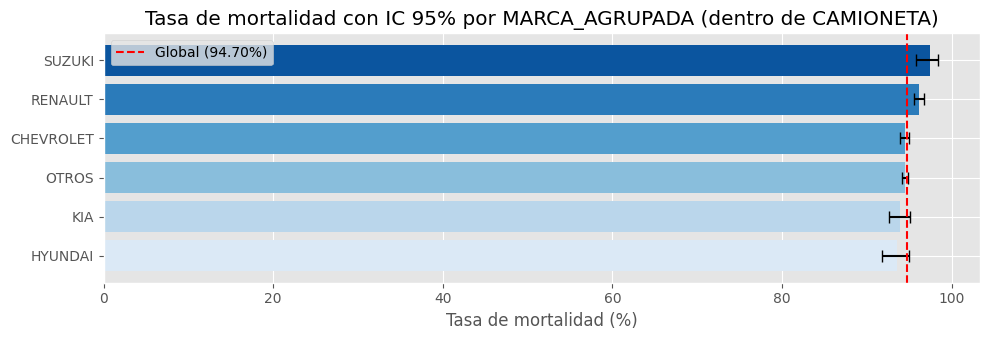


TIPO DE VEHÍCULO: BUS

--- ANÁLISIS: CON MUERTOS ---

TEST DE PROPORCIONES: CON MUERTOS por MARCA_AGRUPADA (dentro de BUS)

Grupos confiables: 2 / 3 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
    OTROS 11304      590    5.22      4.82      5.64      0.82       True
CHEVROLET  4584      235    5.13      4.52      5.80      1.28       True

RANKING (grupos confiables):
   1. OTROS                             5.22%  ███████████████
   2. CHEVROLET                         5.13%  ███████████████


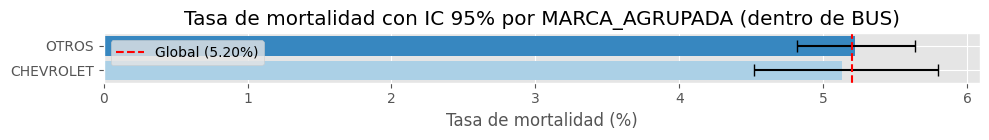


--- ANÁLISIS: CON HERIDOS ---

TEST DE PROPORCIONES: CON HERIDOS por MARCA_AGRUPADA (dentro de BUS)

Grupos confiables: 2 / 3 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
CHEVROLET  4584     4349   94.87     94.20     95.48      1.28       True
    OTROS 11304    10714   94.78     94.36     95.18      0.82       True

RANKING (grupos confiables):
   1. CHEVROLET                        94.87%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. OTROS                            94.78%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

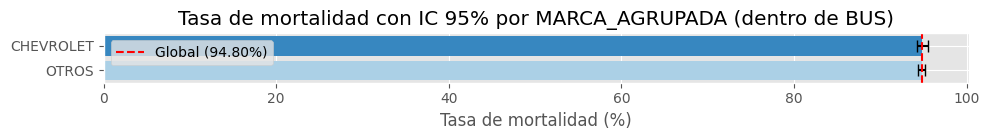


TIPO DE VEHÍCULO: CAMION

--- ANÁLISIS: CON MUERTOS ---

TEST DE PROPORCIONES: CON MUERTOS por MARCA_AGRUPADA (dentro de CAMION)

Grupos confiables: 3 / 5 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo    n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
    OTROS 5911     1072   18.14     17.17     19.14      1.96       True
CHEVROLET 4358      757   17.37     16.27     18.52      2.25       True
  HYUNDAI  239       25   10.46      7.19     14.99      7.80       True

RANKING (grupos confiables):
   1. OTROS                            18.14%  ██████████████████████████████████████████████████████
   2. CHEVROLET                        17.37%  ████████████████████████████████████████████████████
   3. HYUNDAI                          10.46%  ███████████████████████████████


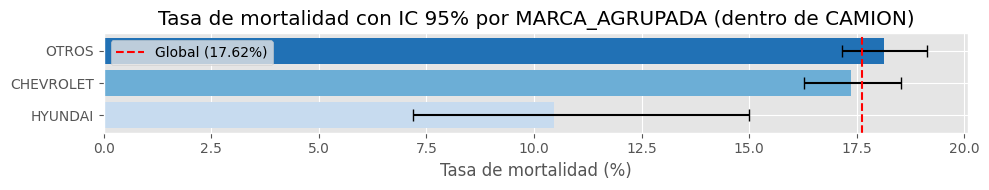


--- ANÁLISIS: CON HERIDOS ---

TEST DE PROPORCIONES: CON HERIDOS por MARCA_AGRUPADA (dentro de CAMION)

Grupos confiables: 3 / 5 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

    Grupo    n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  HYUNDAI  239      214   89.54     85.01     92.81      7.80       True
CHEVROLET 4358     3601   82.63     81.48     83.73      2.25       True
    OTROS 5911     4839   81.86     80.86     82.83      1.96       True

RANKING (grupos confiables):
   1. HYUNDAI                          89.54%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. CHEVROLET                        82.63%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

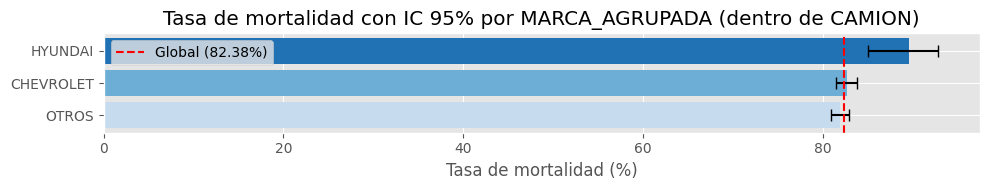

In [157]:
resultados_por_tipo = {}

tipos_principales = df['TIPO_VEHICULO'].value_counts().nlargest(5).index

for tipo in tipos_principales:
    
    print(f"\n{'='*80}")
    print(f"TIPO DE VEHÍCULO: {tipo}")
    print(f"{'='*80}")
    
    df_tipo = df[df['TIPO_VEHICULO'] == tipo].copy()
    
    if len(df_tipo) < 200:
        print("Muestra muy pequeña, se omite.")
        continue
    
    resultados_por_tipo[tipo] = {}
    
    # MUERTOS
    print("\n--- ANÁLISIS: CON MUERTOS ---")
    res_muertos = test_proporciones_confiable(
        df_tipo,
        columna_grupo='MARCA_AGRUPADA',
        categoria='CON MUERTOS',
        titulo=f"(dentro de {tipo})"
    )
    
    resultados_por_tipo[tipo]['MUERTOS'] = res_muertos
    
    # HERIDOS
    print("\n--- ANÁLISIS: CON HERIDOS ---")
    res_heridos = test_proporciones_confiable(
        df_tipo,
        columna_grupo='MARCA_AGRUPADA',
        categoria='CON HERIDOS',
        titulo=f"(dentro de {tipo})"
    )
    
    resultados_por_tipo[tipo]['HERIDOS'] = res_heridos

Dentro del segmento de motos, las diferencias entre marcas (BAJAJ,YAMAHA, AKT, HONDA, OTROS) en tasa de mortalidad son estadísticamente pequeñas y sus
intervalos de confianza se solapan ampliamente. Esto indica que el riesgo es relativamente uniforme entre fabricantes de motos, y que el factor determinante es el tipo de vehículo, no la marca dentro de ese tipo.

Para los automoviles y las camionetas sucede lo mismo, las diferencias entre marcas son marginales una vez controlado el tipo. Las marcas premium no muestran ventaja estadísticamente distinguible respecto a marcas de gama media en términos de mortalidad
de accidentes registrados.

Este resultado valida la decisión de incluir TIPO_VEHICULO como variable principal y MARCA_VEHICULO como complemento secundario.


TEST DE PROPORCIONES: CON MUERTOS por CAT_EDAD_VEHICULO — Objetivo 2 (Muertos)

Grupos confiables: 4 / 4 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

     Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  >20 años  18627     1652    8.87      8.47      9.29      0.82       True
11-20 años  82077     5200    6.34      6.17      6.50      0.33       True
 6-10 años  98880     4886    4.94      4.81      5.08      0.27       True
  0-5 años 128889     6117    4.75      4.63      4.86      0.23       True

RANKING (grupos confiables):
   1. >20 años                          8.87%  ██████████████████████████
   2. 11-20 años                        6.34%  ███████████████████
   3. 6-10 años                         4.94%  ██████████████
   4. 0-5 años                          4.75%  ██████████████


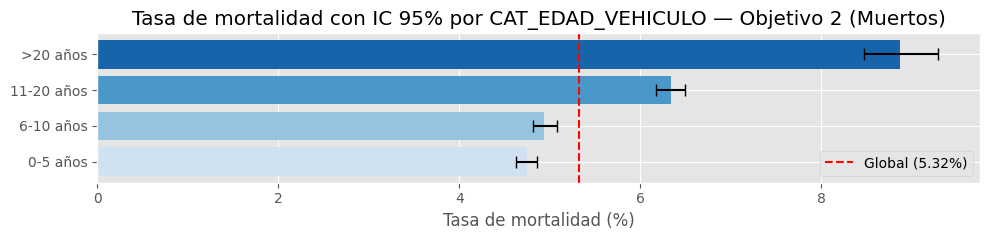


TEST DE PROPORCIONES: CON HERIDOS por CAT_EDAD_VEHICULO — Objetivo 2 (Heridos)

Grupos confiables: 4 / 4 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

     Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  0-5 años 128889   122772   95.25     95.14     95.37      0.23       True
 6-10 años  98880    93994   95.06     94.92     95.19      0.27       True
11-20 años  82077    76877   93.66     93.50     93.83      0.33       True
  >20 años  18627    16975   91.13     90.71     91.53      0.82       True

RANKING (grupos confiables):
   1. 0-5 años                         95.25%  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. 6-10 años                        95.06%  ██████████████████████████████████████████████████

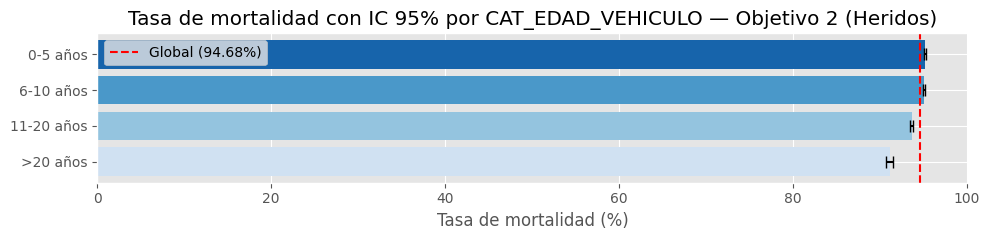

In [ ]:
# MUERTOS
resultado_edad_muertos = test_proporciones_confiable(
    df,
    columna_grupo='CAT_EDAD_VEHICULO',
    categoria='CON MUERTOS',
    muestra_minima=100,
    eventos_minimos=10,
    ancho_ic_max=20,
    titulo='— Objetivo 2 (Muertos)'
)

# CON HERIDOS
resultado_edad_heridos = test_proporciones_confiable(
    df,
    columna_grupo='CAT_EDAD_VEHICULO',
    categoria='CON HERIDOS',
    muestra_minima=100,
    eventos_minimos=10,
    ancho_ic_max=20,
    titulo='— Objetivo 2 (Heridos)'
)

Se observa un aumento progresivo y monótono en la tasa de mortalidad a medida que aumenta la antigüedad del vehículo:

- Vehículos de **0 a 5 años**: tasa por debajo del promedio global. Este grupo
  concentra los modelos con mayor dotación de sistemas de seguridad activa y pasiva
  (ABS, control de estabilidad, airbags de última generación).

- Vehículos de **6 a 10 años**: tasa cercana al promedio global. Corresponde al tramo
  donde los sistemas de seguridad comienzan a presentar desgaste funcional, aunque la
  estructura del vehículo permanece en condiciones aceptables.

- Vehículos de **11 a 20 años**: tasa por encima del promedio global. En este rango,
  la ausencia de tecnologías de seguridad que se normalizaron a partir de 2010
  (asistencia de frenado, control de tracción) se vuelve estadísticamente perceptible.

- Vehículos de **más de 20 años**: tasa significativamente superior al promedio global,
  con intervalos de confianza que no se solapan con los grupos de vehículos nuevos.
  Este grupo representa el perfil de mayor riesgo estructural: desgaste mecánico
  acumulado, ausencia total de tecnología de seguridad moderna y uso intensivo asociado
  a actividades laborales de alta exposición.

El análisis de la tasa de CON HERIDOS por categoría de edad muestra el patrón inverso: vehículos más nuevos presentan mayor tasa de heridos no fatales, lo cual es consistente con la hipótesis de que los sistemas de seguridad modernos no eliminan los accidentes, sino que reducen su letalidad. Un
accidente en un vehículo nuevo es más probable que resulte en herido que en muerto; en un vehículo viejo, la misma colisión tiende hacia el desenlace fatal.


TEST DE PROPORCIONES: CON MUERTOS por DEPARTAMENTO_ACCIDENTE — Objetivo 3 (Muertos)

Grupos confiables: 22 / 31 totales
(Criterios: n≥1000, eventos≥10, Ancho IC≤20%)

             Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
             CESAR   1596      502   31.45     29.22     33.77      4.55       True
         MAGDALENA   3077      569   18.49     17.16     19.90      2.74       True
           CAQUETA   1099      198   18.02     15.86     20.40      4.54       True
             CAUCA   3407      566   16.61     15.40     17.90      2.50       True
           CORDOBA   4068      616   15.14     14.07     16.28      2.20       True
      CUNDINAMARCA  11647     1699   14.59     13.96     15.24      1.28       True
          CASANARE   2581      373   14.45     13.15     15.86      2.71       True
             HUILA   5470      789   14.42     13.52     15.38      1.86       True
            BOYACA   4400      514   11.68     10.77     12.66      1.90    

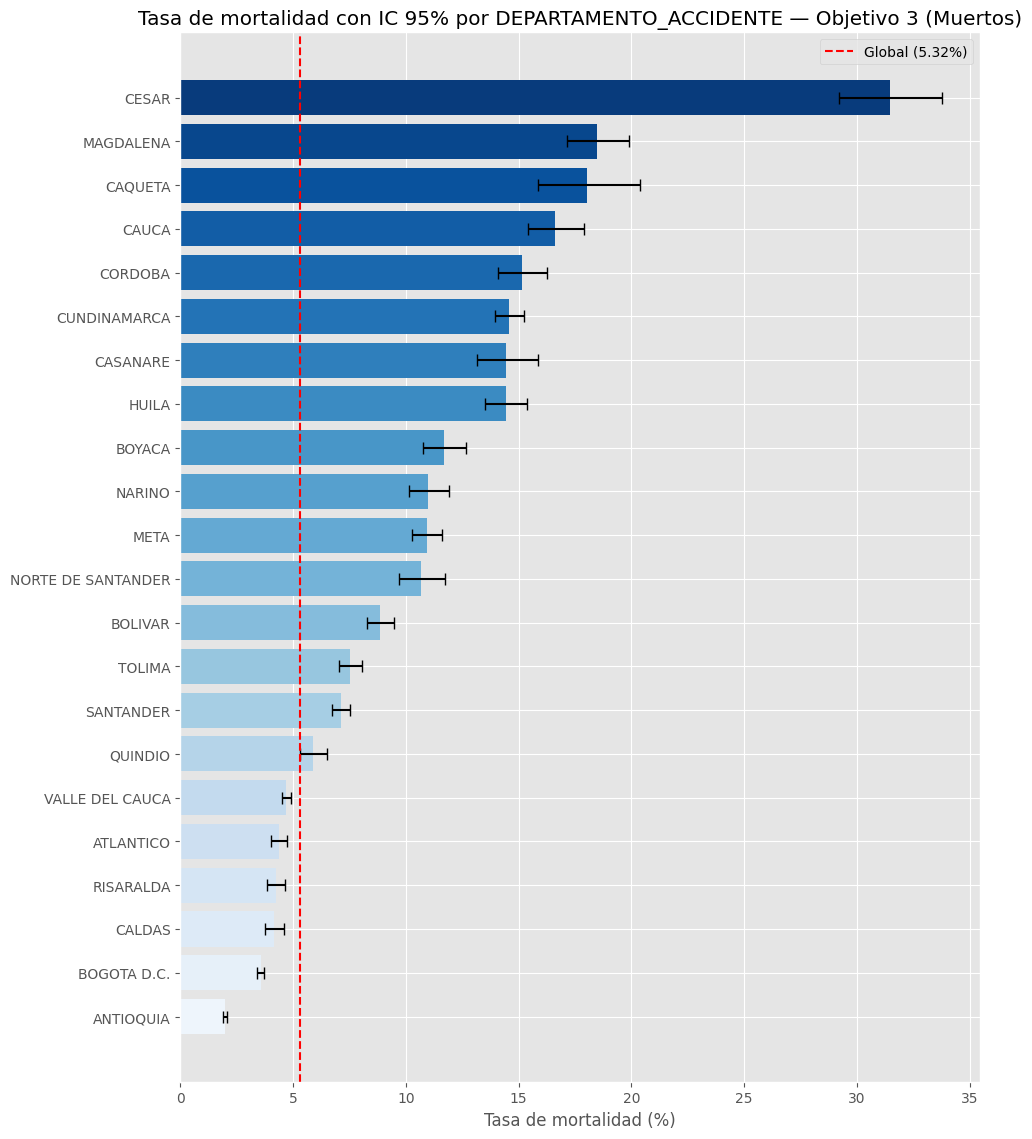


TEST DE PROPORCIONES: CON HERIDOS por DEPARTAMENTO_ACCIDENTE — Objetivo 3 (Heridos)

Grupos confiables: 22 / 31 totales
(Criterios: n≥1000, eventos≥10, Ancho IC≤20%)

             Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
         ANTIOQUIA 138066   135326   98.02     97.94     98.09      0.15       True
       BOGOTA D.C.  60262    58113   96.43     96.28     96.58      0.30       True
            CALDAS   8497     8144   95.85     95.40     96.25      0.85       True
         RISARALDA  10638    10188   95.77     95.37     96.14      0.77       True
         ATLANTICO  13350    12767   95.63     95.27     95.97      0.69       True
   VALLE DEL CAUCA  48538    46257   95.30     95.11     95.49      0.38       True
           QUINDIO   5927     5578   94.11     93.48     94.68      1.20       True
         SANTANDER  16413    15244   92.88     92.47     93.26      0.79       True
            TOLIMA  10673     9870   92.48     91.96     92.96      1.00    

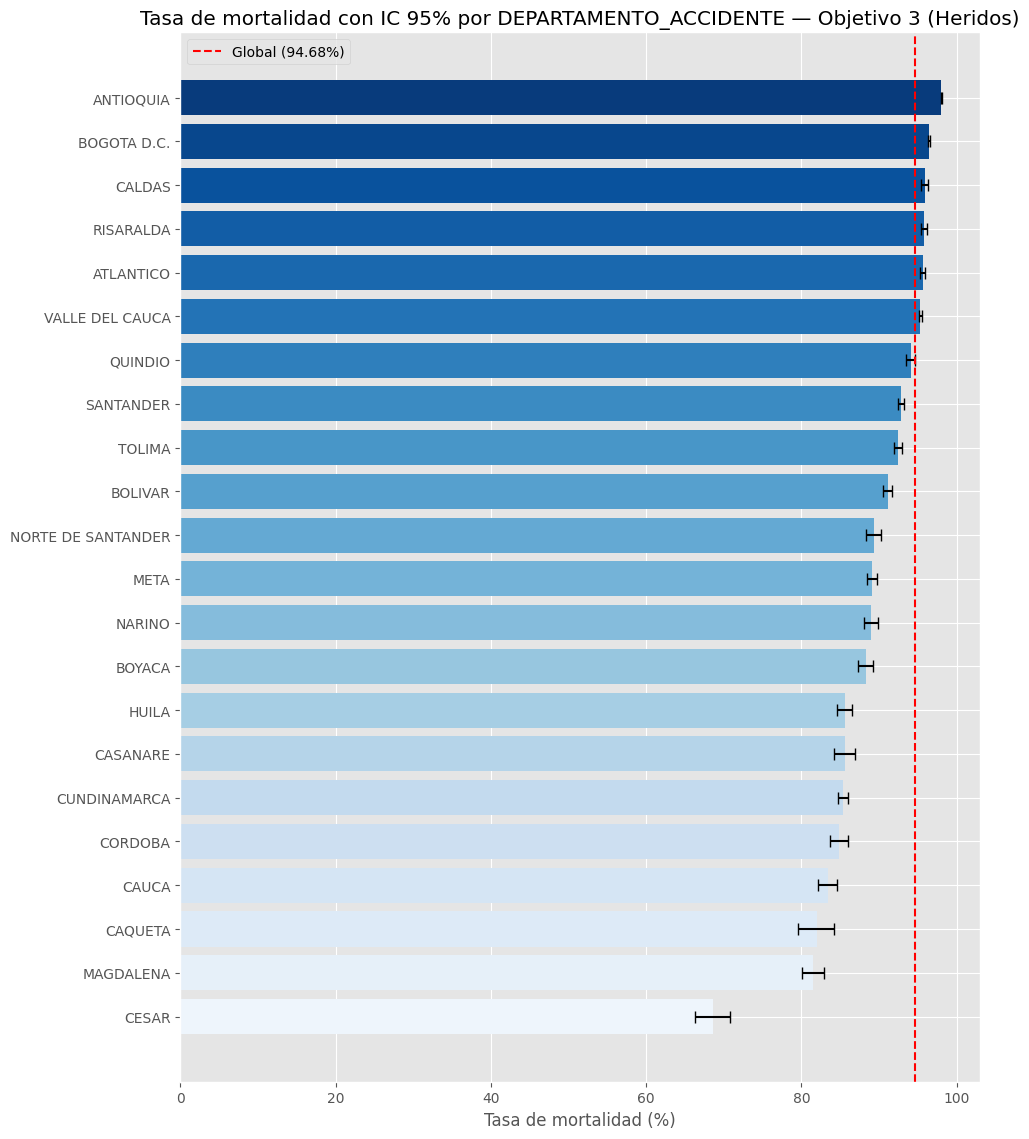

In [159]:
# CON MUERTOS
resultado_dep_muertos = test_proporciones_confiable(
    df,
    columna_grupo='DEPARTAMENTO_ACCIDENTE',
    categoria='CON MUERTOS',
    muestra_minima=1000,
    eventos_minimos=10,
    ancho_ic_max=20,
    titulo='— Objetivo 3 (Muertos)'
)

# CON HERIDOS
resultado_dep_heridos = test_proporciones_confiable(
    df,
    columna_grupo='DEPARTAMENTO_ACCIDENTE',
    categoria='CON HERIDOS',
    muestra_minima=1000,
    eventos_minimos=10,
    ancho_ic_max=20,
    titulo='— Objetivo 3 (Heridos)'
)

Los departamentos con mayor volumen de accidentes (Antioquia, Bogotá D.C., Valle del Cauca) presentan tasas de mortalidad por debajo del promedio global, mientras que departamentos con menor volumen de registros presentan las tasas más altas del ranking. Los intervalos de confianza de Wilson para estos grupos no se solapan, descartando el azar como explicación.

**Departamentos de alto volumen / baja mortalidad:** La concentración de accidentes en zonas urbanas densamente pobladas coexiste con mejor infraestructura de respuesta médica de emergencia (tiempos de traslado menores a centros hospitalarios), mayor presencia de autoridades de tránsito que registran incluso siniestros menores, y mayor proporción de accidentes de baja velocidad en contexto urbano (embotellamientos, intersecciones señalizadas).

**Departamentos de bajo volumen / alta mortalidad:** Los departamentos periféricos del ranking concentran accidentes en vías intermunicipales de alta velocidad, con menor densidad de centros hospitalarios y mayor tiempo de respuesta de emergencias. Un accidente grave en una vía rural remota tiene mayor probabilidad de resultar fatal por razones logísticas independientes del vehículo.

El análisis de CON HERIDOS por departamento presenta el ordenamiento opuesto al de CON MUERTOS: los departamentos más urbanos concentran mayor tasa de heridos, porque registran sistemáticamente más accidentes leves que los departamentos periféricos (donde el subregistro de siniestros no fatales es mayor). Esto sugiere que la comparación entre departamentos debe hacerse con cautela: la tasa de mortalidad observada puede estar inflada en regiones con menor cobertura de registro de accidentes leves.

### 9.4 Correlaciones entre variables numéricas

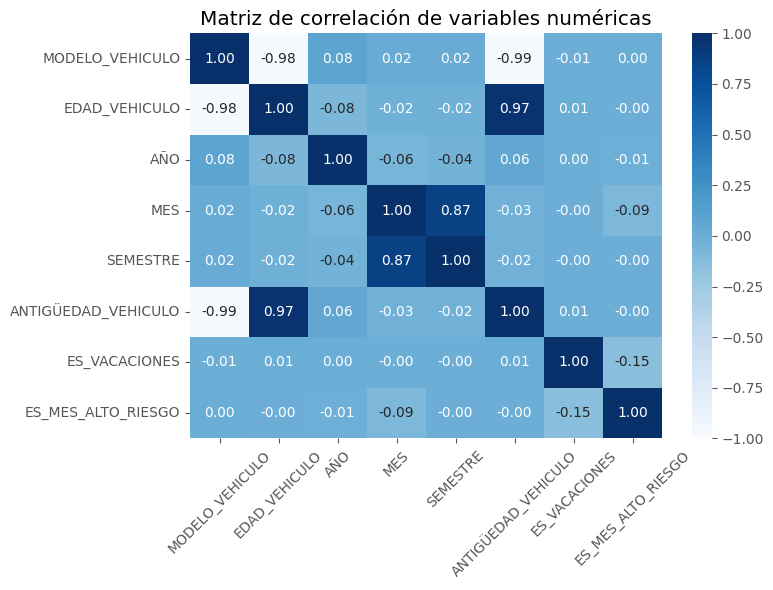

In [150]:
df_num = df.select_dtypes(include='number')
corr = df_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Matriz de correlación de variables numéricas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En las variables `MODELO_VEHICULO` y `EDAD_VEHICULO` tienen correlación perfecta negativa (−1): se calculan de la misma fuente. **No se deben incluir ambas en el modelo** — se recomienda usar `EDAD_VEHICULO` o `ANTIGÜEDAD_VEHICULO`.

Y en las variables `MES` y `SEMESTRE` están altamente correlacionadas entre sí — son transformaciones del mismo dato temporal. Se recomienda usar solo una de ellas.

## 10. Conclusiones, limitaciones y preparación para modelado

**Objetivo 1 — Marca, modelo y tipo de vehículo vs. gravedad**

El análisis confirmó que el **tipo de vehículo** es el predictor más relevante dentro
de las características del vehículo, con una V de Cramér superior a la de la marca
aislada. Los vehículos de carga pesada (tractocamión, volqueta, camión) registran tasas
de mortalidad entre 3 y 6 veces el promedio global (~5%), con intervalos de confianza
que no se solapan con los de los demás tipos, descartando el azar como explicación.

La **marca del vehículo**, analizada de forma aislada, presenta asociación débil con
la gravedad. Sin embargo, al controlar por tipo de vehículo, se evidencia que las
diferencias entre marcas dentro de un mismo segmento son estadísticamente marginales:
el riesgo lo determina el tipo, no el fabricante. Las marcas más frecuentes en el
dataset (BAJAJ, YAMAHA, CHEVROLET) reflejan el parque automotor nacional, no un
riesgo diferencial inherente.

**Objetivo 2 — Antigüedad del vehículo vs. gravedad**

La prueba de Kolmogorov-Smirnov confirmó la no normalidad de `EDAD_VEHICULO`,
validando el uso de Mann-Whitney U como prueba principal (p < 0.001). El análisis por
categorías de antigüedad reveló un **gradiente de riesgo monótono**: a mayor antigüedad,
mayor tasa de mortalidad. Los vehículos de más de 20 años presentan la tasa más alta
del ranking, con intervalos de confianza que no se solapan con los de vehículos nuevos
(0–5 años). Este patrón se explica por la ausencia de sistemas de seguridad activa
(ABS, ESC) y pasiva (airbags) en modelos anteriores a 2005, el mayor desgaste mecánico
acumulado y su uso intensivo en actividades laborales de alta exposición al riesgo.

**Objetivo 3 — Concentración espacial y patrones temporales**

El hallazgo geográfico central es la **paradoja volumen/letalidad**: los departamentos
con mayor número de accidentes (Antioquia, Bogotá, Valle del Cauca) presentan tasas
de mortalidad por debajo del promedio global, mientras que departamentos periféricos
registran las tasas más altas. La explicación estructural apunta a la diferencia en
tiempos de acceso hospitalario y a la mayor proporción de accidentes en vías
intermunicipales de alta velocidad en las regiones remotas.

En la dimensión temporal, los datos confirman patrones predecibles: julio concentra el
mayor volumen mensual (vacaciones de mitad de año), los fines de semana presentan
tasas de mortalidad superiores al promedio global (conducción recreativa y nocturna),
y se identificaron picos recurrentes en diciembre-enero. Esta predictibilidad temporal
es precisamente lo que hace viable un modelo de Machine Learning para anticipar
escenarios de alto riesgo.

---

### 10.2 Limitaciones del estudio

| # | Limitación | Impacto en el análisis |
|---|---|---|
| 1 | **Unidad de análisis es el vehículo, no el accidente.** Un siniestro entre 3 vehículos genera 3 registros. | Los conteos absolutos sobreestiman el número de eventos reales. |
| 2 | **Variable objetivo binaria** (CON HERIDOS / CON MUERTOS). | Reduce la granularidad predictiva respecto a estudios con 4 niveles de severidad. |
| 3 | **Sin hora del accidente.** | Impide analizar patrones horarios (madrugada vs. hora pico), predictores clave en la literatura. |
| 4 | **Ausencia de variables contextuales** (clima, tipo de vía, velocidad, alcohol). | El modelo opera solo sobre características del vehículo y contexto espacio-temporal. |
| 5 | **Alta cardinalidad** en AUTORIDAD_DE_TRANSITO (232 variantes) y MUNICIPIO_ACCIDENTE (1,000+). | Requieren normalización o agrupación antes del modelado para evitar sobreajuste. |
| 6 | **Anomalía de julio 2024** (22,667 registros inválidos de una sola autoridad). | Fue detectada y excluida; de no haberlo hecho, habría distorsionado toda la serie temporal. |

---

### 10.3 Variables seleccionadas para el modelo predictivo

```python
# Variables INCLUIR en el modelo
INCLUIR = {
    'TIPO_VEHICULO'          : 'Mayor V de Cramér entre variables del vehículo',
    'MODELO_ESPECIFICO'      : 'Captura variación interna dentro de cada marca',
    'EDAD_VEHICULO'          : 'Predictor significativo — Kruskal-Wallis p < 0.001',
    'CAT_EDAD_VEHICULO'      : 'Versión categorizada para modelos de árbol',
    'DEPARTAMENTO_ACCIDENTE' : 'V de Cramér moderada — diferencias geográficas reales',
    'SEMESTRE'               : 'Estacionalidad sin multicolinealidad con MES',
    'ES_VACACIONES'          : 'Feature booleana de estacionalidad',
    'DIA_SEMANA'             : 'Efecto fin de semana confirmado en tasa de mortalidad',
}

# Variables EXCLUIR y razón
EXCLUIR = {
    'MODELO_VEHICULO'                    : 'Correlación perfecta con EDAD_VEHICULO (r = -1.0)',
    'MES + TRIMESTRE + SEMESTRE juntos'  : 'Alta multicolinealidad entre los tres',
    'AUTORIDAD_DE_TRANSITO'              : '232 variantes — normalización pendiente',
    'MUNICIPIO_ACCIDENTE'                : 'Alta cardinalidad — riesgo de sobreajuste',
}
```